# Polymarket Buyer Risk Scoring Using Orderbook Anomaly Detection

This notebook builds a Spark-based MVP pipeline for Polymarket orderbook data.

## Project idea

The goal is to create a **buyer-risk screening tool** for prediction markets. The notebook looks for **manipulation-like orderbook signals** that can make a market risky for buyers, such as:

- wide or unstable bid-ask spreads
- sudden price movement
- sudden activity spikes
- large orderbook changes
- one-sided buy/sell pressure
- liquidity stress

## Important framing

The output is a **Buyer Risk Score**.

A high score means:

> This market-window showed several abnormal orderbook signals, not necessarily outright fraud.

## Quick Glossary of Core Risk Concepts

| Concept | Meaning in this notebook |
|---|---|
| `best_bid` | Highest price currently offered by buyers |
| `best_ask` | Lowest price currently offered by sellers |
| `spread` | Difference between best ask and best bid |
| `mid_price` | Approximate market price, usually halfway between bid and ask |
| `change_size` | Size of an orderbook update |
| `change_side` | Whether the update happened on the BUY or SELL side |
| `tick_count` | Number of orderbook updates in a time window |
| `price_range` | Difference between highest and lowest mid-price in a window |
| `imbalance_score` | How one-sided the BUY/SELL pressure is |
| `anomaly_count` | Number of abnormality rules triggered |
| `risk_score` | Weighted 0–100 buyer-risk score |

The risk score is intentionally explainable. Each point comes from a visible flag, not from a black-box model.


# Integrated Report: Polymarket Buyer Risk Scoring Using Orderbook Anomaly Detection

## Executive Summary

This project builds a Spark-based pipeline that analyzes Polymarket tick-level orderbook data and converts raw market activity into a buyer-focused risk ranking. The notebook flags markets that show **manipulation-like or abnormal orderbook behavior** based on observable signals such as bid-ask spread movement, price movement, orderbook activity, large order changes, buy/sell pressure, and liquidity stress.

The resulting output is a **Buyer Risk Score**, scaled from 0 to 100. Higher scores indicate that a market-window triggered more abnormal risk signals. The score is designed as a screening tool: it helps identify markets that may deserve closer review before a user treats market prices as reliable event probabilities.

The project is implemented as a **Minimum Viable Product (MVP)**. It prioritizes explainability, Spark scalability, and restartability through saved Parquet checkpoints. Because Spark sessions can die during large computations, the notebook stores key processed tables so that later runs can resume without repeating the most expensive raw orderbook aggregation.

## Main Deliverables

1. A Spark pipeline that loads Polymarket labels and orderbook data.
2. A resumable checkpoint structure for processed intermediate tables.
3. Market-window feature engineering using 1-hour windows.
4. Rule-based anomaly flags for abnormal orderbook behavior.
5. A 0–100 Buyer Risk Score.
6. Market-level risk rankings.
7. Category-level risk summaries using keyword-based topic classification.
8. Explainability fields showing the main risk driver for each flagged market.

## Important Framing

This notebook should be interpreted as a **risk screening system**, not a fraud accusation system. A high Buyer Risk Score means the market displayed abnormal orderbook behavior within the analyzed period. It does not establish trader intent, legal manipulation, spoofing, wash trading, or fraud.

## Problem Statement

Prediction markets such as Polymarket express market-implied probabilities for real-world events. Users may treat these prices as signals of expected outcomes. However, some markets can be thin, unstable, or affected by short bursts of abnormal orderbook activity. These conditions can expose buyers to poor execution, misleading prices, or increased uncertainty.

The project addresses the following question:

> Which Polymarket markets show abnormal orderbook behavior that may create buyer risk?

A secondary question is:

> Are abnormal signals concentrated in specific market topics, such as politics, crypto, sports, technology, economy, or entertainment?

## Dataset and Scope

The notebook uses Polymarket Parquet data consisting mainly of:

| Data Source | Role in the Pipeline |
|---|---|
| `labels/market_targets.parquet` | Market metadata such as market question, volume, liquidity, closed status, YES/NO token IDs, and target where available. |
| `orderbook/orderbook_2026-03-06.parquet` | Tick-level orderbook activity including timestamps, market ID, bid/ask prices, spread, mid-price, change size, change side, and token ID. |

The available orderbook fields make it possible to compute spread behavior, price behavior, activity intensity, buy/sell pressure, and liquidity stress. However, the MVP does not use full orderbook depth beyond the fields available in the selected file. This means deeper market-manipulation patterns such as confirmed layering or spoofing can only be approximated indirectly, not proven.

## Methodology Overview

The notebook follows a staged Spark pipeline:

```text
Load raw data
→ validate schema and join keys
→ keep labeled/interpretable markets
→ clean timestamps and categories
→ filter active markets
→ create 1-hour market windows
→ engineer orderbook features
→ create anomaly flags
→ calculate Buyer Risk Score
→ aggregate to market level
→ classify topics using keywords
→ summarize by market and category
→ save final outputs and checkpoints
```

### NOTE: Why 1-Hour Market Windows?

The raw data is tick-level, which is too granular for direct interpretation. The notebook groups activity into 1-hour windows so each row represents one market during one hour. This provides a balance: short enough to catch abnormal bursts, but not so short that the results become overly noisy.

## Buyer Risk Score Design

The Buyer Risk Score is an explainable, rule-based score ranging from 0 to 100. It combines multiple abnormal orderbook signals into one screening indicator.

### Feature Groups

| Feature Group | Example Metrics | Buyer-Risk Logic |
|---|---|---|
| Spread behavior | Average spread, maximum spread, spread volatility | Wide or unstable spreads mean buyers may face worse execution and weaker liquidity. |
| Price behavior | Mid-price range and volatility proxy | Sharp price changes can indicate unstable market probability or abnormal trading bursts. |
| Activity behavior | Tick count and total change size | Sudden spikes in orderbook updates may indicate unusual attention or trading pressure. |
| Order size behavior | Maximum change size and total change size | Very large orderbook changes may signal abnormal pressure or liquidity movement. |
| Buy/sell pressure | Buy pressure, sell pressure, imbalance score | Extreme one-sided pressure may indicate directional crowding or abnormal orderbook behavior. |
| Liquidity stress | Wide spread combined with low activity | Buyers may have difficulty entering or exiting at fair prices. |

### Anomaly Flags

The notebook first converts numeric features into binary flags. Each flag equals 1 if a market-window is abnormal by the selected threshold and 0 otherwise.

| Flag | Meaning |
|---|---|
| `spread_spike_flag` | Average spread is unusually high. |
| `spread_instability_flag` | Spread movement is unusually unstable. |
| `price_jump_flag` | Mid-price movement within the window is unusually large. |
| `activity_spike_flag` | Tick activity is unusually high. |
| `large_order_flag` | Maximum orderbook change size is unusually large. |
| `high_volume_change_flag` | Total orderbook change size is unusually high. |
| `imbalance_flag` | Buy-side or sell-side pressure dominates the window. |
| `liquidity_stress_flag` | Spread is high while activity is low. |

### Score Formula

The MVP Buyer Risk Score is calculated as:

```text
Buyer Risk Score =
  20 × spread_spike_flag
+ 15 × spread_instability_flag
+ 20 × price_jump_flag
+ 15 × activity_spike_flag
+ 10 × large_order_flag
+ 10 × high_volume_change_flag
+  5 × imbalance_flag
+  5 × liquidity_stress_flag
```

The maximum score is 100.

### Why These Weights?

The weights are not copied from a single academic paper. They are an explainable MVP design based on the relative buyer impact of each signal.

| Component | Weight | Reason |
|---|---:|---|
| Spread spike | 20 | Directly affects buyer execution cost and liquidity quality. |
| Price jump | 20 | Captures large probability movement and potential price instability. |
| Spread instability | 15 | Indicates changing and unreliable liquidity conditions. |
| Activity spike | 15 | Captures abnormal bursts in orderbook activity. |
| Large order | 10 | Captures unusual orderbook size movements. |
| High volume/change | 10 | Captures unusually large total orderbook changes. |
| Buy/sell imbalance | 5 | Useful supporting indicator of one-sided pressure. |
| Liquidity stress | 5 | Supporting signal of thin or difficult-to-trade markets. |

### Score Interpretation

| Score Range | Interpretation |
|---:|---|
| 0–24 | Low observed buyer risk |
| 25–49 | Moderate observed buyer risk |
| 50–74 | High observed buyer risk |
| 75–100 | Very high observed buyer risk |

A high score means the market-window triggered multiple abnormal orderbook conditions. It does not prove fraud or manipulation.

## Results Interpretation Guide

The notebook produces two main output tables.

### 1. Final Market Ranking

The final market ranking aggregates 1-hour scores into one row per market. Important columns include:

| Column | Interpretation |
|---|---|
| `avg_risk_score` | Average risk across all market-windows. Higher values imply sustained abnormality. |
| `max_risk_score` | Highest observed hourly risk. Useful for detecting one-time spikes. |
| `high_risk_windows` | Number of windows with high or very high risk. |
| `very_high_risk_windows` | Number of windows with score of 75 or above. |
| `high_risk_window_rate` | Share of windows that were high risk. Useful for sustained abnormality. |
| `overall_avg_spread` | Average spread across windows. Higher values suggest weaker liquidity. |
| `max_price_range` | Largest price movement observed in a window. |
| `avg_imbalance_score` | Average buy/sell imbalance. Values closer to 1 indicate more one-sided pressure. |
| `main_risk_driver` | Most frequent reason the market was flagged. |

Markets should not be ranked only by `max_risk_score`. A single extreme window can produce a high maximum score. For screening purposes, the notebook prioritizes sustained abnormal behavior through `high_risk_window_rate`, `avg_risk_score`, and `total_anomaly_count`.

### 2. Category Summary

The category summary groups markets into keyword-based topic categories such as politics/elections, crypto, sports, technology/AI, economy/finance, world events/geopolitics, entertainment, science/health, and other.

This table helps answer whether abnormal signals are broad across the dataset or concentrated in certain topics. A category with many markets may naturally have more total high-risk windows, so both average risk and total flagged windows should be interpreted together.

## 1. Imports and Spark Setup

This section starts the Spark environment and imports the tools used throughout the notebook.


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from functools import reduce
from pathlib import Path
from datetime import datetime
import os
import shutil
import json
import pandas as pd
import matplotlib.pyplot as plt

spark = (
    SparkSession.builder
    .appName("Polymarket Buyer Risk Scoring")
    # Fewer shuffle partitions is usually friendlier for a single-machine/student VM setup.
    .config("spark.sql.shuffle.partitions", "64")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
spark


## 2. Path Configuration

This section defines where the input data comes from and where processed outputs will be saved.

### Input data used in this MVP

- `labels/market_targets.parquet` contains market metadata such as market question, volume, liquidity, close status, and YES/NO token IDs.
- `orderbook/orderbook_2026-03-06.parquet` contains tick-level orderbook updates such as bid, ask, spread, mid-price, order side, and order size.

### Output structure

The notebook uses a restartable output structure:

- **Silver layer**: cleaned and joined intermediate data.
- **Gold layer**: analysis-ready features, scores, and final outputs.
- **Export layer**: CSV-style outputs for easier inspection and reporting.


In [135]:
BASE_PATH = "/mnt/data/public/polymarket"

LABELS_PATH = f"{BASE_PATH}/labels/market_targets.parquet"
ORDERBOOK_PATH = f"{BASE_PATH}/orderbook/orderbook_2026-03-06.parquet"

# -----------------------------
# Resumable pipeline settings
# -----------------------------
# Set FORCE_REBUILD = True only if you want to recompute everything from raw data.
FORCE_REBUILD = False

# Save intermediate tables so the notebook can resume after Spark/session restarts.
SAVE_INTERMEDIATE = True

# Use relative paths so Spark can write inside the current working directory.
OUTPUT_ROOT = os.path.abspath("polymarket_outputs")
RUN_NAME = "orderbook_2026_03_06_mvp"
RUN_PATH = os.path.join(OUTPUT_ROOT, RUN_NAME)

SILVER_PATH = os.path.join(RUN_PATH, "silver")
GOLD_PATH = os.path.join(RUN_PATH, "gold")
EXPORT_PATH = os.path.join(RUN_PATH, "exports")

for path in [OUTPUT_ROOT, RUN_PATH, SILVER_PATH, GOLD_PATH, EXPORT_PATH]:
    os.makedirs(path, exist_ok=True)

# Checkpoint paths
OB_LABELED_PATH = os.path.join(SILVER_PATH, "ob_labeled")
OB_LABELED_CLEAN_PATH = os.path.join(SILVER_PATH, "ob_labeled_clean")
MARKET_ACTIVITY_PATH = os.path.join(SILVER_PATH, "market_activity")
ACTIVE_MARKETS_PATH = os.path.join(SILVER_PATH, "active_markets")

FEATURES_PATH = os.path.join(GOLD_PATH, "market_window_features")
SCORED_WINDOWS_PATH = os.path.join(GOLD_PATH, "scored_market_windows")
MARKET_SCORES_PATH = os.path.join(GOLD_PATH, "market_scores")
MARKET_SCORES_CATEGORIZED_PATH = os.path.join(GOLD_PATH, "market_scores_categorized")
MARKET_SCORES_EXPLAINED_PATH = os.path.join(GOLD_PATH, "market_scores_explained")
FINAL_MARKET_RANKING_PATH = os.path.join(GOLD_PATH, "final_market_ranking")
FINAL_CATEGORY_SUMMARY_PATH = os.path.join(GOLD_PATH, "final_category_summary")

print("Labels path:", LABELS_PATH)
print("Orderbook path:", ORDERBOOK_PATH)
print("Run path:", RUN_PATH)
print("Force rebuild:", FORCE_REBUILD)


Labels path: /mnt/data/public/polymarket/labels/market_targets.parquet
Orderbook path: /mnt/data/public/polymarket/orderbook/orderbook_2026-03-06.parquet
Run path: /home2/msds2026/laltonaga/polymarket_outputs/orderbook_2026_03_06_mvp
Force rebuild: False


## 2A. Checkpoint Helpers

This section makes the notebook **resumable**.

### How checkpoint logic works

Most heavy cells follow this pattern:

1. Check if a saved Parquet output already exists.
2. If it exists and `FORCE_REBUILD = False`, load the saved checkpoint.
3. If it does not exist, compute the DataFrame.
4. Save the result as a checkpoint.
5. Reload from checkpoint when needed to cut Spark lineage.

### Controls

- `FORCE_REBUILD = False` means reuse saved checkpoints when available.
- `SAVE_INTERMEDIATE = True` means save important intermediate tables.
- Changing `FORCE_REBUILD` to `True` forces the notebook to recompute everything.


In [3]:
def parquet_exists(path):
    """Return True when a Spark Parquet folder exists and contains part files."""
    p = Path(path)
    if not p.exists() or not p.is_dir():
        return False
    return any(p.rglob("*.parquet"))

def should_load_checkpoint(path):
    """Load existing checkpoint unless FORCE_REBUILD is enabled."""
    return (not FORCE_REBUILD) and parquet_exists(path)

def any_checkpoint_exists(paths):
    return any(should_load_checkpoint(p) for p in paths)

def downstream_checkpoint_exists():
    """True when later compact outputs already exist, so earlier heavy raw steps can be skipped."""
    return any_checkpoint_exists([
        FEATURES_PATH,
        SCORED_WINDOWS_PATH,
        MARKET_SCORES_PATH,
        MARKET_SCORES_CATEGORIZED_PATH,
        MARKET_SCORES_EXPLAINED_PATH,
        FINAL_MARKET_RANKING_PATH,
        FINAL_CATEGORY_SUMMARY_PATH,
    ])

def load_checkpoint(path, name="checkpoint"):
    print(f"Loading {name} from: {path}")
    return spark.read.parquet(path)

def save_checkpoint(df, path, name="checkpoint", reload_after_save=True, coalesce_to=None):
    """Save a Spark DataFrame as Parquet and optionally reload it to break lineage."""
    if SAVE_INTERMEDIATE:
        df_to_write = df.coalesce(coalesce_to) if coalesce_to else df
        df_to_write.write.mode("overwrite").parquet(path)
        print(f"Saved {name} to: {path}")
        if reload_after_save:
            return spark.read.parquet(path)
    return df

def checkpoint_status():
    paths = {
        "ob_labeled_clean": OB_LABELED_CLEAN_PATH,
        "market_activity": MARKET_ACTIVITY_PATH,
        "active_markets": ACTIVE_MARKETS_PATH,
        "market_window_features": FEATURES_PATH,
        "scored_market_windows": SCORED_WINDOWS_PATH,
        "market_scores": MARKET_SCORES_PATH,
        "market_scores_categorized": MARKET_SCORES_CATEGORIZED_PATH,
        "market_scores_explained": MARKET_SCORES_EXPLAINED_PATH,
        "final_market_ranking": FINAL_MARKET_RANKING_PATH,
        "final_category_summary": FINAL_CATEGORY_SUMMARY_PATH,
    }
    for name, path in paths.items():
        print(f"{name:28s}", "FOUND" if parquet_exists(path) else "missing", "-", path)

checkpoint_status()


ob_labeled_clean             FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/silver/ob_labeled_clean
market_activity              FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/silver/market_activity
active_markets               FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/silver/active_markets
market_window_features       FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/market_window_features
scored_market_windows        FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/scored_market_windows
market_scores                FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/market_scores

## 3. Load Data and Inspect Schemas

This section loads the raw input files and inspects their structure.

### Inspecting schemas

Before building features, we need to confirm which columns are actually available. The project depends on specific fields:

From the labels table:

- `condition_id` for market ID
- `question` for market title
- `closed` for unresolved/resolved status
- `volume` and `liquidity` for active-market filtering
- `clob_token_id_yes` and `clob_token_id_no` for outcome token mapping

From the orderbook table:

- `market_id` for market ID
- `timestamp_received` for event time
- `best_bid`, `best_ask`, `spread`, and `mid_price` for price/liquidity behavior
- `change_size` and `change_side` for orderbook pressure

### What this step produces

This step creates:

- `df_labels`: raw market metadata
- `df_ob`: raw orderbook ticks for one selected day
- `df_labels_meta`: cleaned label metadata using `market_id` as the standard key


In [137]:
# Load labels first. This table is small enough and is needed for metadata even when resuming.

df_labels = spark.read.parquet(LABELS_PATH)

df_labels_meta = (
    df_labels
    .select(
        F.col("condition_id").alias("market_id"),
        "question",
        "category",
        "end_date",
        "closed",
        "uma_status",
        F.coalesce(F.col("volume"), F.lit(0.0)).alias("volume"),
        F.coalesce(F.col("liquidity"), F.lit(0.0)).alias("liquidity"),
        "clob_token_id_yes",
        "clob_token_id_no",
        "target"
    )
    .withColumn(
        "category_clean",
        F.when(
            (F.col("category").isNull()) | (F.trim(F.col("category")) == ""),
            F.lit("uncategorized")
        ).otherwise(F.col("category"))
    )
)

# Load the large raw orderbook only if no usable checkpoint is available.
RAW_ORDERBOOK_NEEDED = (
    FORCE_REBUILD
    or not any_checkpoint_exists([
        OB_LABELED_PATH,
        OB_LABELED_CLEAN_PATH,
        FEATURES_PATH,
        SCORED_WINDOWS_PATH,
        MARKET_SCORES_PATH,
        FINAL_MARKET_RANKING_PATH,
        FINAL_CATEGORY_SUMMARY_PATH,
    ])
)

if RAW_ORDERBOOK_NEEDED:
    df_ob = spark.read.parquet(ORDERBOOK_PATH)
    RAW_INPUTS_LOADED = True

    print("Labels schema:")
    df_labels.printSchema()

    print("Orderbook schema:")
    df_ob.printSchema()

    df_labels.show(5, truncate=False)
    df_ob.show(5, truncate=False)
else:
    RAW_INPUTS_LOADED = False
    print("Existing checkpoint found. Skipping raw orderbook load for faster resume.")
    print("df_labels and df_labels_meta were still loaded.")


Labels schema:
root
 |-- condition_id: string (nullable = true)
 |-- question: string (nullable = true)
 |-- category: string (nullable = true)
 |-- end_date: string (nullable = true)
 |-- closed: boolean (nullable = true)
 |-- uma_status: string (nullable = true)
 |-- volume: double (nullable = true)
 |-- liquidity: double (nullable = true)
 |-- clob_token_id_yes: string (nullable = true)
 |-- clob_token_id_no: string (nullable = true)
 |-- target: byte (nullable = true)

Orderbook schema:
root
 |-- timestamp_received: long (nullable = true)
 |-- timestamp_created_at: long (nullable = true)
 |-- market_id: string (nullable = true)
 |-- best_bid: float (nullable = true)
 |-- best_ask: float (nullable = true)
 |-- change_price: float (nullable = true)
 |-- change_size: float (nullable = true)
 |-- change_side: string (nullable = true)
 |-- token_id: string (nullable = true)
 |-- spread: float (nullable = true)
 |-- mid_price: float (nullable = true)

+-----------------------------------

In [5]:
# Basic counts
# These are expensive on full raw data, so they run only when raw inputs were loaded.

if RAW_INPUTS_LOADED:
    print("Labels rows:", df_labels.count())
    print("Orderbook rows:", df_ob.count())

    df_labels.select(
        F.countDistinct("condition_id").alias("distinct_condition_ids"),
        F.countDistinct("question").alias("distinct_questions")
    ).show()

    df_ob.select(
        F.countDistinct("market_id").alias("distinct_market_ids"),
        F.countDistinct("token_id").alias("distinct_token_ids")
    ).show()
else:
    print("Skipped raw input counts because the notebook is resuming from checkpoints.")

Skipped raw input counts because the notebook is resuming from checkpoints.


## 4. Data Quality Checks

This section checks whether important fields are missing or blank.

### Why we do Data Quality Checks

Missing IDs, timestamps, spread values, or market questions can break the analysis or produce misleading results. For example:

- If `market_id` is missing, the orderbook row cannot be linked to a market.
- If `question` is missing, final outputs are not interpretable.
- If `spread` or `mid_price` is missing, risk metrics cannot be calculated.
- If `category` is blank, we need to create our own topic classification later.

### What to look for

The important output is not just whether nulls exist, but whether nulls appear in columns needed for scoring and joining.


In [6]:
# Check missing / blank important fields
# These checks run only when raw inputs were loaded.

if RAW_INPUTS_LOADED:
    df_labels.select(
        F.count("*").alias("rows"),
        F.sum(F.when(F.col("condition_id").isNull(), 1).otherwise(0)).alias("null_condition_id"),
        F.sum(F.when(F.col("question").isNull(), 1).otherwise(0)).alias("null_question"),
        F.sum(F.when((F.col("category").isNull()) | (F.trim(F.col("category")) == ""), 1).otherwise(0)).alias("blank_category"),
        F.sum(F.when(F.col("volume").isNull(), 1).otherwise(0)).alias("null_volume"),
        F.sum(F.when(F.col("liquidity").isNull(), 1).otherwise(0)).alias("null_liquidity")
    ).show()

    df_ob.select(
        F.count("*").alias("rows"),
        F.sum(F.when(F.col("market_id").isNull(), 1).otherwise(0)).alias("null_market_id"),
        F.sum(F.when(F.col("token_id").isNull(), 1).otherwise(0)).alias("null_token_id"),
        F.sum(F.when(F.col("best_bid").isNull(), 1).otherwise(0)).alias("null_best_bid"),
        F.sum(F.when(F.col("best_ask").isNull(), 1).otherwise(0)).alias("null_best_ask"),
        F.sum(F.when(F.col("spread").isNull(), 1).otherwise(0)).alias("null_spread"),
        F.sum(F.when(F.col("mid_price").isNull(), 1).otherwise(0)).alias("null_mid_price")
    ).show()
else:
    print("Skipped raw data quality checks because the notebook is resuming from checkpoints.")

Skipped raw data quality checks because the notebook is resuming from checkpoints.


## 5. Validate Join Strategy

This section checks how orderbook rows connect to market metadata.

### Why we validate

The labels table uses `condition_id`, while the orderbook table uses `market_id`. We need to verify whether:

```text
orderbook.market_id = labels.condition_id
```

The notebook also checks whether token IDs improve the match:

```text
orderbook.token_id = labels.clob_token_id_yes or labels.clob_token_id_no
```

### What this step decides

This step determines the usable market universe for the MVP.


In [7]:
# Direct market ID match: orderbook.market_id = labels.condition_id
# Run only when raw inputs were loaded.

if RAW_INPUTS_LOADED:
    df_ob_markets = df_ob.select("market_id").distinct()

    df_label_ids = df_labels.select(
        F.col("condition_id").alias("market_id"),
        "question",
        "category",
        "volume",
        "liquidity",
        "clob_token_id_yes",
        "clob_token_id_no"
    )

    df_join_test = df_ob_markets.join(df_label_ids, on="market_id", how="left")

    df_join_test.select(
        F.count("*").alias("distinct_orderbook_markets"),
        F.count("question").alias("matched_to_labels"),
        (F.count("question") / F.count("*")).alias("match_rate")
    ).show()

    print("Sample unmatched markets:")
    df_join_test.filter(F.col("question").isNull()).show(10, truncate=False)
else:
    print("Skipped join validation because the notebook is resuming from checkpoints.")

Skipped join validation because the notebook is resuming from checkpoints.


In [8]:
# Token-based match check
# Run only when raw inputs were loaded.

if RAW_INPUTS_LOADED:
    df_label_tokens = (
        df_labels
        .select(
            "condition_id",
            "question",
            "category",
            "volume",
            "liquidity",
            F.col("clob_token_id_yes").alias("token_id"),
            F.lit("YES").alias("outcome_side")
        )
        .unionByName(
            df_labels.select(
                "condition_id",
                "question",
                "category",
                "volume",
                "liquidity",
                F.col("clob_token_id_no").alias("token_id"),
                F.lit("NO").alias("outcome_side")
            )
        )
    )

    df_token_join_test = (
        df_ob.select("market_id", "token_id").distinct()
        .join(df_label_tokens, on="token_id", how="left")
    )

    df_market_match_by_token = (
        df_token_join_test
        .groupBy("market_id")
        .agg(
            F.max(F.when(F.col("question").isNotNull(), 1).otherwise(0)).alias("has_token_match")
        )
    )

    df_market_match_by_token.select(
        F.count("*").alias("distinct_orderbook_markets"),
        F.sum("has_token_match").alias("markets_matched_by_token"),
        (F.sum("has_token_match") / F.count("*")).alias("market_token_match_rate")
    ).show()
else:
    print("Skipped token join validation because the notebook is resuming from checkpoints.")

Skipped token join validation because the notebook is resuming from checkpoints.


### Join Decision

The MVP keeps only markets that successfully join to the labels table.

### Why unmatched markets are excluded

Unmatched markets may still have valid orderbook behavior, but they cannot be interpreted properly because they lack market questions and metadata. Since this project is a buyer-risk screening tool, final outputs must show which market was flagged and why.

### Practical implication

This makes the analysis more interpretable but reduces coverage. The results should be described as applying to the **matched labeled subset**, not necessarily the entire Polymarket dataset.


In [9]:
# Create / load labeled orderbook checkpoint.
# This is a heavy table, so later compact checkpoints skip this step.

if downstream_checkpoint_exists():
    print("Downstream checkpoint exists. Skipping labeled orderbook creation.")

elif should_load_checkpoint(OB_LABELED_CLEAN_PATH):
    df_ob_labeled = load_checkpoint(OB_LABELED_CLEAN_PATH, "clean labeled orderbook")

elif should_load_checkpoint(OB_LABELED_PATH):
    df_ob_labeled = load_checkpoint(OB_LABELED_PATH, "labeled orderbook")

else:
    if 'df_ob' not in globals():
        print("Loading raw orderbook because no labeled checkpoint exists.")
        df_ob = spark.read.parquet(ORDERBOOK_PATH)

    # Inner join retains only interpretable markets.
    df_ob_labeled = (
        df_ob
        .join(df_labels_meta, on="market_id", how="inner")
        .withColumn(
            "outcome_side",
            F.when(F.col("token_id") == F.col("clob_token_id_yes"), F.lit("YES"))
             .when(F.col("token_id") == F.col("clob_token_id_no"), F.lit("NO"))
             .otherwise(F.lit("UNKNOWN"))
        )
    )

    df_ob_labeled = save_checkpoint(df_ob_labeled, OB_LABELED_PATH, "labeled orderbook")

if 'df_ob_labeled' in globals():
    df_ob_labeled.select(
        "market_id",
        "question",
        "category_clean",
        "outcome_side",
        "change_side",
        "best_bid",
        "best_ask",
        "spread",
        "mid_price",
        "change_price",
        "change_size",
        "volume",
        "liquidity"
    ).show(10, truncate=False)


Downstream checkpoint exists. Skipping labeled orderbook creation.


In [10]:
# Check how much orderbook data remains after joining with labels
# Skip this count when raw inputs were not loaded or when resuming from feature checkpoints.

if RAW_INPUTS_LOADED and not should_load_checkpoint(FEATURES_PATH):
    total_ob_rows = df_ob.count()
    labeled_ob_rows = df_ob_labeled.count()

    print("Total orderbook rows:", total_ob_rows)
    print("Labeled orderbook rows:", labeled_ob_rows)
    print("Row retention rate:", labeled_ob_rows / total_ob_rows if total_ob_rows > 0 else None)
else:
    print("Skipped row retention count during checkpoint resume.")

Skipped row retention count during checkpoint resume.


## 6. Clean Category and Convert Timestamp

This section prepares the joined orderbook table for time-based analysis.

### Category cleaning

The original `category` field is often blank. The notebook first replaces blank categories with `uncategorized`. Later, it creates stronger topic categories using keyword rules from the market question.

### Timestamp conversion

The raw `timestamp_received` column is stored as Unix time in milliseconds. It is converted to Spark timestamp format so Spark can create time windows.

The conversion logic is:

```text
timestamp_received milliseconds
→ divide by 1000
→ convert to Unix seconds
→ convert to Spark timestamp
```


In [11]:
# Clean timestamp and save clean labeled checkpoint.
# If later compact checkpoints already exist, this heavy table is not needed.

if downstream_checkpoint_exists():
    print("Downstream checkpoint exists. Skipping clean labeled orderbook creation.")

elif should_load_checkpoint(OB_LABELED_CLEAN_PATH):
    df_ob_labeled = load_checkpoint(OB_LABELED_CLEAN_PATH, "clean labeled orderbook")

else:
    if 'df_ob_labeled' not in globals():
        if should_load_checkpoint(OB_LABELED_PATH):
            df_ob_labeled = load_checkpoint(OB_LABELED_PATH, "labeled orderbook")
        else:
            raise RuntimeError("df_ob_labeled is missing. Run the labeled orderbook creation cell first.")

    df_ob_labeled = (
        df_ob_labeled
        .withColumn(
            "category_clean",
            F.when(
                (F.col("category").isNull()) | (F.trim(F.col("category")) == ""),
                F.lit("uncategorized")
            ).otherwise(F.col("category"))
        )
        .withColumn(
            "event_time",
            F.to_timestamp(
                F.from_unixtime((F.col("timestamp_received") / F.lit(1000)).cast("long"))
            )
        )
    )

    df_ob_labeled = save_checkpoint(df_ob_labeled, OB_LABELED_CLEAN_PATH, "clean labeled orderbook")

if 'df_ob_labeled' in globals():
    df_ob_labeled.select(
        "timestamp_received",
        "event_time",
        "market_id",
        "question",
        "best_bid",
        "best_ask",
        "spread",
        "mid_price"
    ).show(10, truncate=False)


Downstream checkpoint exists. Skipping clean labeled orderbook creation.


## 7. Active Market Filtering

This section removes inactive, resolved, or extremely thin markets.

The MVP focuses on markets that are active enough to analyze meaningfully.

### Filtering logic

The notebook uses:

- `closed = False` to focus on unresolved markets
- minimum `volume`
- minimum `liquidity`
- minimum `tick_count`

The idea is:

> A market should have enough trading interest and enough orderbook activity before we assign a buyer-risk score.

### Performance note

The notebook uses a lightweight activity calculation: it groups by `market_id` first, then joins the market question and metadata afterward. This avoids shuffling long text fields such as market questions across millions of rows.


In [12]:
# Labeled data size and time range
# Skip this expensive count if market-window features already exist.

if should_load_checkpoint(FEATURES_PATH):
    print("Feature checkpoint exists. Skipping labeled data size check.")
else:
    df_ob_labeled.select(
        F.count("*").alias("rows"),
        F.countDistinct("market_id").alias("distinct_markets"),
        F.min("event_time").alias("min_event_time"),
        F.max("event_time").alias("max_event_time")
    ).show(truncate=False)

Feature checkpoint exists. Skipping labeled data size check.


In [13]:
# Lightweight market-level activity summary.
# Important fix: group only by market_id, then join metadata after.
# This avoids shuffling long question/category strings across millions of rows.

if should_load_checkpoint(FEATURES_PATH) or should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Feature/scored checkpoint exists. Skipping market activity computation.")

elif should_load_checkpoint(MARKET_ACTIVITY_PATH):
    df_market_activity = load_checkpoint(MARKET_ACTIVITY_PATH, "market activity")

else:
    if 'df_ob_labeled' not in globals():
        if should_load_checkpoint(OB_LABELED_CLEAN_PATH):
            df_ob_labeled = load_checkpoint(OB_LABELED_CLEAN_PATH, "clean labeled orderbook")
        elif should_load_checkpoint(OB_LABELED_PATH):
            df_ob_labeled = load_checkpoint(OB_LABELED_PATH, "labeled orderbook")
            df_ob_labeled = df_ob_labeled.withColumn(
                "event_time",
                F.to_timestamp(
                    F.from_unixtime((F.col("timestamp_received") / F.lit(1000)).cast("long"))
                )
            )
        else:
            raise RuntimeError("No labeled orderbook checkpoint found. Run the labeled orderbook cells first.")

    df_market_activity_core = (
        df_ob_labeled
        .select("market_id", "event_time", "spread", "mid_price")
        .filter(F.col("event_time").isNotNull())
        .groupBy("market_id")
        .agg(
            F.count("*").alias("tick_count"),
            F.min("event_time").alias("first_seen"),
            F.max("event_time").alias("last_seen"),
            F.avg("spread").alias("avg_spread"),
            F.avg("mid_price").alias("avg_mid_price")
        )
    )

    df_market_activity = (
        df_market_activity_core
        .join(
            df_labels_meta.select(
                "market_id",
                "question",
                "category_clean",
                "closed",
                "volume",
                "liquidity"
            ),
            on="market_id",
            how="left"
        )
        .select(
            "market_id",
            "question",
            "category_clean",
            "closed",
            "volume",
            "liquidity",
            "tick_count",
            "first_seen",
            "last_seen",
            "avg_spread",
            "avg_mid_price"
        )
    )

    df_market_activity = save_checkpoint(
        df_market_activity,
        MARKET_ACTIVITY_PATH,
        "market activity",
        coalesce_to=8
    )

if 'df_market_activity' in globals():
    df_market_activity.orderBy(F.desc("tick_count")).show(10, truncate=False)


Feature/scored checkpoint exists. Skipping market activity computation.


In [14]:
# Compute thresholds for filtering active markets.
# This runs only if we still need to build the feature table.

if should_load_checkpoint(FEATURES_PATH) or should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Feature/scored checkpoint exists. Skipping active-market threshold computation.")
else:
    if 'df_market_activity' not in globals():
        df_market_activity = load_checkpoint(MARKET_ACTIVITY_PATH, "market activity")

    volume_bounds = df_market_activity.approxQuantile("volume", [0.50, 0.95, 0.9975], 0.01)
    liquidity_bounds = df_market_activity.approxQuantile("liquidity", [0.50, 0.95, 0.9975], 0.01)
    tick_bounds = df_market_activity.approxQuantile("tick_count", [0.50, 0.75, 0.90], 0.01)

    print("Volume percentiles [50%, 95%, 99.75%]:", volume_bounds)
    print("Liquidity percentiles [50%, 95%, 99.75%]:", liquidity_bounds)
    print("Tick count percentiles [50%, 75%, 90%]:", tick_bounds)


Feature/scored checkpoint exists. Skipping active-market threshold computation.


In [15]:
# Filter active and unresolved markets.

if should_load_checkpoint(FEATURES_PATH) or should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Feature/scored checkpoint exists. Skipping active-market filtering.")

elif should_load_checkpoint(ACTIVE_MARKETS_PATH):
    df_active_markets = load_checkpoint(ACTIVE_MARKETS_PATH, "active markets")

else:
    if 'df_market_activity' not in globals():
        df_market_activity = load_checkpoint(MARKET_ACTIVITY_PATH, "market activity")

    min_volume = volume_bounds[0]
    min_liquidity = liquidity_bounds[0]
    min_tick_count = 100

    df_active_markets = (
        df_market_activity
        .filter(F.col("closed") == False)
        .filter(F.col("volume") >= min_volume)
        .filter(F.col("liquidity") >= min_liquidity)
        .filter(F.col("tick_count") >= min_tick_count)
    )

    df_active_markets = save_checkpoint(
        df_active_markets,
        ACTIVE_MARKETS_PATH,
        "active markets",
        coalesce_to=8
    )

if 'df_active_markets' in globals():
    df_active_markets.select(F.count("*").alias("active_markets")).show()
    df_active_markets.orderBy(F.desc("tick_count")).show(10, truncate=False)


Feature/scored checkpoint exists. Skipping active-market filtering.


In [16]:
# Keep only active orderbook rows.
# This table is intentionally not saved because it can be very large.
# The compact market-window feature table is saved in the next section.

if should_load_checkpoint(FEATURES_PATH) or should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Feature/scored checkpoint exists. Skipping active orderbook row join.")

else:
    if 'df_ob_labeled' not in globals():
        df_ob_labeled = load_checkpoint(OB_LABELED_CLEAN_PATH, "clean labeled orderbook")
    if 'df_active_markets' not in globals():
        df_active_markets = load_checkpoint(ACTIVE_MARKETS_PATH, "active markets")

    df_ob_active = (
        df_ob_labeled
        .select(
            "market_id",
            "event_time",
            "token_id",
            "spread",
            "mid_price",
            "change_size",
            "change_side"
        )
        .join(
            df_active_markets.select("market_id"),
            on="market_id",
            how="inner"
        )
    )

    df_ob_active.select(
        F.count("*").alias("active_orderbook_rows"),
        F.countDistinct("market_id").alias("active_orderbook_markets")
    ).show()


Feature/scored checkpoint exists. Skipping active orderbook row join.


## 8. Market-Time Window Feature Engineering

This is the main data transformation step.

### Goal

Convert raw tick-level orderbook data into a smaller feature table where each row represents:

```text
one market + one 1-hour window
```

### Why 1-hour windows?

Tick data is too granular for direct market-level scoring. One-hour windows provide a balance:

- short enough to capture abnormal bursts
- long enough to reduce noise
- small enough to compare behavior across markets

### Main engineered features

| Feature | Meaning |
|---|---|
| `tick_count` | Number of orderbook updates in the window |
| `avg_spread` | Average bid-ask spread |
| `spread_volatility` | Spread instability, approximated as max spread minus min spread |
| `price_range` | Mid-price movement, computed as max mid-price minus min mid-price |
| `total_change_size` | Total size of orderbook changes |
| `max_change_size` | Largest observed orderbook change |
| `buy_pressure` | Total change size on BUY side |
| `sell_pressure` | Total change size on SELL side |
| `imbalance_score` | Degree of one-sided pressure |

### Imbalance formula

```text
imbalance_score = abs(buy_pressure - sell_pressure) / (buy_pressure + sell_pressure)
```

A score near 0 means balanced activity. A score near 1 means one side dominates the orderbook updates.


In [17]:
# Avoid caching the 60M+ active orderbook rows in memory.
# The expensive result we actually want to preserve is df_features, saved in the next cell.

if should_load_checkpoint(FEATURES_PATH) or should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Feature/scored checkpoint exists. Skipping active data cache.")
else:
    print("Skipping cache for df_ob_active to avoid Spark JVM memory pressure.")


Feature/scored checkpoint exists. Skipping active data cache.


In [18]:
# Create 1-hour time windows.

if should_load_checkpoint(FEATURES_PATH) or should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Feature/scored checkpoint exists. Skipping time-window base creation.")
else:
    df_window_base = (
        df_ob_active
        .filter(F.col("event_time").isNotNull())
        .filter(F.col("spread").isNotNull())
        .filter(F.col("mid_price").isNotNull())
        .withColumn("time_window", F.window("event_time", "1 hour"))
        .withColumn("window_start", F.col("time_window.start"))
        .withColumn("window_end", F.col("time_window.end"))
    )


Feature/scored checkpoint exists. Skipping time-window base creation.


In [19]:
# Safe-mode market-window feature creation
# This version is lighter and less likely to crash Spark.
# It removes expensive countDistinct, percentile_approx, and stddev.
# Spread volatility is approximated as max_spread - min_spread.
# Mid-price volatility is approximated as max_mid_price - min_mid_price.

import os
import shutil

# If a previous write died halfway, remove incomplete checkpoint folder
if os.path.exists(FEATURES_PATH) and not os.path.exists(os.path.join(FEATURES_PATH, "_SUCCESS")):
    print("Removing incomplete feature checkpoint...")
    shutil.rmtree(FEATURES_PATH)

# Controls
MAX_ACTIVE_MARKETS = 1500      # reduce if Spark still dies; try 750 or 500
SAMPLE_FRACTION = 0.20         # use 20% of ticks for MVP; set to 1.0 for full run later
RANDOM_SEED = 42

if should_load_checkpoint(FEATURES_PATH):
    df_features = load_checkpoint(FEATURES_PATH, "market-window features")

elif should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Scored window checkpoint exists. Skipping feature creation.")

else:
    if "df_window_base" not in globals():
        raise RuntimeError("df_window_base is missing. Run the time-window creation cell first.")

    # Limit to most active markets first.
    # This keeps the MVP stable and avoids trying to process all active markets at once.
    df_active_market_subset = (
        df_active_markets
        .orderBy(F.desc("tick_count"))
        .limit(MAX_ACTIVE_MARKETS)
        .select("market_id", "question", "category_clean")
        .dropDuplicates(["market_id"])
    )

    # Keep only required columns and only selected markets
    df_window_safe = (
        df_window_base
        .select(
            "market_id",
            "window_start",
            "window_end",
            "token_id",
            "spread",
            "mid_price",
            "change_size",
            "change_side"
        )
        .join(
            F.broadcast(df_active_market_subset.select("market_id")),
            on="market_id",
            how="inner"
        )
        .filter(F.col("spread").isNotNull())
        .filter(F.col("mid_price").isNotNull())
        .filter(F.col("change_size").isNotNull())
    )

    # Optional sampling to avoid crashing the Spark backend
    if SAMPLE_FRACTION < 1.0:
        df_window_safe = df_window_safe.sample(
            withReplacement=False,
            fraction=SAMPLE_FRACTION,
            seed=RANDOM_SEED
        )

    # Repartition before aggregation
    df_window_safe = df_window_safe.repartition(64, "market_id", "window_start")

    # Lightweight aggregation
    df_features_core = (
        df_window_safe
        .groupBy(
            "market_id",
            "window_start",
            "window_end"
        )
        .agg(
            # Activity
            F.count("*").alias("tick_count"),

            # Spread behavior
            F.avg("spread").alias("avg_spread"),
            F.min("spread").alias("min_spread"),
            F.max("spread").alias("max_spread"),

            # Price behavior
            F.avg("mid_price").alias("avg_mid_price"),
            F.min("mid_price").alias("min_mid_price"),
            F.max("mid_price").alias("max_mid_price"),

            # Orderbook change behavior
            F.sum("change_size").alias("total_change_size"),
            F.avg("change_size").alias("avg_change_size"),
            F.max("change_size").alias("max_change_size"),

            # Buy / sell pressure
            F.sum(
                F.when(F.col("change_side") == "BUY", F.col("change_size")).otherwise(0)
            ).alias("buy_pressure"),

            F.sum(
                F.when(F.col("change_side") == "SELL", F.col("change_size")).otherwise(0)
            ).alias("sell_pressure")
        )
        .withColumn("median_spread", F.col("avg_spread"))  # lightweight proxy
        .withColumn("spread_volatility", F.col("max_spread") - F.col("min_spread"))
        .withColumn("price_range", F.col("max_mid_price") - F.col("min_mid_price"))
        .withColumn("mid_price_volatility", F.col("price_range"))  # lightweight proxy
        .withColumn("total_pressure", F.col("buy_pressure") + F.col("sell_pressure"))
        .withColumn(
            "imbalance_score",
            F.when(
                F.col("total_pressure") > 0,
                F.abs(F.col("buy_pressure") - F.col("sell_pressure")) / F.col("total_pressure")
            ).otherwise(0)
        )
        .withColumn("distinct_tokens", F.lit(None).cast("int"))
        .fillna({
            "avg_spread": 0.0,
            "min_spread": 0.0,
            "max_spread": 0.0,
            "median_spread": 0.0,
            "spread_volatility": 0.0,
            "avg_mid_price": 0.0,
            "min_mid_price": 0.0,
            "max_mid_price": 0.0,
            "mid_price_volatility": 0.0,
            "total_change_size": 0.0,
            "avg_change_size": 0.0,
            "max_change_size": 0.0,
            "buy_pressure": 0.0,
            "sell_pressure": 0.0,
            "price_range": 0.0,
            "total_pressure": 0.0,
            "imbalance_score": 0.0
        })
    )

    df_features = (
        df_features_core
        .join(df_active_market_subset, on="market_id", how="left")
        .select(
            "market_id",
            "question",
            "category_clean",
            "window_start",
            "window_end",
            "tick_count",
            "distinct_tokens",
            "avg_spread",
            "median_spread",
            "max_spread",
            "spread_volatility",
            "avg_mid_price",
            "min_mid_price",
            "max_mid_price",
            "mid_price_volatility",
            "total_change_size",
            "avg_change_size",
            "max_change_size",
            "buy_pressure",
            "sell_pressure",
            "price_range",
            "total_pressure",
            "imbalance_score"
        )
    )

    # Save with repartition, not coalesce.
    # Coalesce can create large partitions and crash local Spark.
    (
        df_features
        .repartition(32, "market_id")
        .write
        .mode("overwrite")
        .parquet(FEATURES_PATH)
    )

    # Reload from checkpoint to cut lineage
    df_features = load_checkpoint(FEATURES_PATH, "market-window features")

df_features.select(
    F.count("*").alias("market_window_rows"),
    F.countDistinct("market_id").alias("markets")
).show()

df_features.select(
    "market_id",
    "question",
    "category_clean",
    "window_start",
    "window_end",
    "tick_count",
    "avg_spread",
    "median_spread",
    "spread_volatility",
    "price_range",
    "total_change_size",
    "buy_pressure",
    "sell_pressure",
    "imbalance_score"
).orderBy(F.desc("tick_count")).show(10, truncate=False)

Loading market-window features from: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/market_window_features
+------------------+-------+
|market_window_rows|markets|
+------------------+-------+
|             35957|   1500|
+------------------+-------+

+------------------------------------------------------------------+-----------------------------------------------------------+--------------+-------------------+-------------------+----------+--------------------+--------------------+-----------------+-----------+------------------+------------------+------------------+--------------------+
|market_id                                                         |question                                                   |category_clean|window_start       |window_end         |tick_count|avg_spread          |median_spread       |spread_volatility|price_range|total_change_size |buy_pressure      |sell_pressure     |imbalance_score

## 9. Anomaly Flag Creation

This section converts numeric market-window features into binary anomaly flags.

The notebook needs an explainable score. Instead of using a black-box model, each risk signal is visible as a 0/1 flag.

A flag value of `1` means:

> This market-window triggered that abnormality rule.

A flag value of `0` means:

> This market-window did not trigger that rule.

### Threshold logic

Most flags use percentile thresholds computed from the feature table. For example:

- values above the 95th percentile are treated as unusually high
- values below the 25th percentile can be treated as unusually low
- liquidity stress combines high spread with low activity

### Why percentiles?

Percentiles are simple, scalable, and explainable. They also work better than fixed cutoffs because different datasets can have different spread, activity, and volume distributions.

### Flags created

| Flag | Meaning |
|---|---|
| `spread_spike_flag` | Average spread is unusually high |
| `spread_instability_flag` | Spread movement is unusually unstable |
| `price_jump_flag` | Mid-price range is unusually large |
| `activity_spike_flag` | Tick activity is unusually high |
| `large_order_flag` | A very large orderbook change appeared |
| `high_volume_change_flag` | Total orderbook change size is unusually high |
| `imbalance_flag` | Buy or sell side heavily dominates |
| `liquidity_stress_flag` | Spread is high while activity is low |

### Anomaly count

The notebook also computes:

```text
anomaly_count = sum of all anomaly flags
```

This gives a simple count of how many abnormal signals appeared in a market-window.


In [20]:
# Persist feature table only when scoring still needs it.

if should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Scored market-window checkpoint exists. Skipping df_features cache.")
elif 'df_features' in globals():
    df_features = df_features.persist()
    df_features.count()
else:
    print("df_features is not loaded because the notebook is resuming from a later checkpoint.")


Scored market-window checkpoint exists. Skipping df_features cache.


In [21]:
# Compute percentile thresholds for anomaly flags.
# Skip if scored market-window checkpoint already exists.

if should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Scored market-window checkpoint exists. Skipping threshold computation.")

else:
    if 'df_features' not in globals():
        df_features = load_checkpoint(FEATURES_PATH, "market-window features")

    feature_cols = [
        "avg_spread",
        "spread_volatility",
        "price_range",
        "tick_count",
        "max_change_size",
        "total_change_size",
        "imbalance_score"
    ]

    quantile_probs = [0.25, 0.50, 0.75, 0.95]

    quantile_values = df_features.approxQuantile(feature_cols, quantile_probs, 0.01)

    thresholds = {
        col: {
            "q25": vals[0],
            "q50": vals[1],
            "q75": vals[2],
            "q95": vals[3]
        }
        for col, vals in zip(feature_cols, quantile_values)
    }

    print(thresholds)


Scored market-window checkpoint exists. Skipping threshold computation.


In [22]:
# Create explainable anomaly flags

if should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Scored market-window checkpoint exists. Skipping flag creation.")

else:
    df_flags = (
        df_features
        .withColumn(
            "spread_spike_flag",
            F.when(F.col("avg_spread") >= F.lit(thresholds["avg_spread"]["q95"]), 1).otherwise(0)
        )
        .withColumn(
            "spread_instability_flag",
            F.when(F.col("spread_volatility") >= F.lit(thresholds["spread_volatility"]["q95"]), 1).otherwise(0)
        )
        .withColumn(
            "price_jump_flag",
            F.when(F.col("price_range") >= F.lit(thresholds["price_range"]["q95"]), 1).otherwise(0)
        )
        .withColumn(
            "activity_spike_flag",
            F.when(F.col("tick_count") >= F.lit(thresholds["tick_count"]["q95"]), 1).otherwise(0)
        )
        .withColumn(
            "large_order_flag",
            F.when(F.col("max_change_size") >= F.lit(thresholds["max_change_size"]["q95"]), 1).otherwise(0)
        )
        .withColumn(
            "high_volume_change_flag",
            F.when(F.col("total_change_size") >= F.lit(thresholds["total_change_size"]["q95"]), 1).otherwise(0)
        )
        .withColumn(
            "imbalance_flag",
            F.when(
                (F.col("imbalance_score") >= F.lit(0.80)) &
                (F.col("total_pressure") > 0),
                1
            ).otherwise(0)
        )
        .withColumn(
            "liquidity_stress_flag",
            F.when(
                (F.col("avg_spread") >= F.lit(thresholds["avg_spread"]["q75"])) &
                (F.col("tick_count") <= F.lit(thresholds["tick_count"]["q25"])),
                1
            ).otherwise(0)
        )
    )

    df_flags.select(
        F.sum("spread_spike_flag").alias("spread_spike_windows"),
        F.sum("spread_instability_flag").alias("spread_instability_windows"),
        F.sum("price_jump_flag").alias("price_jump_windows"),
        F.sum("activity_spike_flag").alias("activity_spike_windows"),
        F.sum("large_order_flag").alias("large_order_windows"),
        F.sum("high_volume_change_flag").alias("high_volume_change_windows"),
        F.sum("imbalance_flag").alias("imbalance_windows"),
        F.sum("liquidity_stress_flag").alias("liquidity_stress_windows")
    ).show()

Scored market-window checkpoint exists. Skipping flag creation.


In [23]:
# Count total anomaly flags per market-window

if should_load_checkpoint(SCORED_WINDOWS_PATH):
    print("Scored market-window checkpoint exists. Skipping anomaly count creation.")

else:
    flag_cols = [
        "spread_spike_flag",
        "spread_instability_flag",
        "price_jump_flag",
        "activity_spike_flag",
        "large_order_flag",
        "high_volume_change_flag",
        "imbalance_flag",
        "liquidity_stress_flag"
    ]

    df_flags = df_flags.withColumn(
        "anomaly_count",
        reduce(lambda a, b: a + b, [F.col(c) for c in flag_cols])
    )

    df_flags.select(
        "market_id",
        "question",
        "category_clean",
        "window_start",
        "window_end",
        "tick_count",
        "avg_spread",
        "spread_volatility",
        "price_range",
        "imbalance_score",
        "anomaly_count"
    ).orderBy(F.desc("anomaly_count"), F.desc("tick_count")).show(20, truncate=False)

Scored market-window checkpoint exists. Skipping anomaly count creation.


## 10. Buyer Risk / Manipulation-Likelihood Score

This section combines anomaly flags into a 0–100 score.

### What the score means

The Buyer Risk Score is an explainable risk indicator based on abnormal orderbook behavior. It is designed to answer:

> Which market-windows look risky for buyers based on spread, price, activity, order size, imbalance, and liquidity signals?

The score does **not** prove fraud or manipulation.

### Score formula

The notebook uses a weighted sum:

```text
risk_score =
    20 × spread_spike_flag
  + 15 × spread_instability_flag
  + 20 × price_jump_flag
  + 15 × activity_spike_flag
  + 10 × large_order_flag
  + 10 × high_volume_change_flag
  +  5 × imbalance_flag
  +  5 × liquidity_stress_flag
```

The maximum score is 100.

### Why these weights?

Higher weights are assigned to signals that are more directly related to buyer execution risk and manipulation-like behavior:

- **Spread spike** and **price jump** receive high weights because they directly affect the price a buyer may pay.
- **Spread instability** and **activity spike** receive medium-high weights because they indicate unstable market conditions.
- **Large order** and **high volume change** receive medium weights because they may indicate abnormal orderbook pressure.
- **Imbalance** and **liquidity stress** receive smaller weights because they are useful supporting signals but can occur naturally in thin markets.

### Risk bands

| Score range | Risk band | Meaning |
|---:|---|---|
| 0–24 | Low | Few or no abnormal signals |
| 25–49 | Moderate | Some abnormal behavior |
| 50–74 | High | Multiple abnormal signals |
| 75–100 | Very High | Strong abnormality across several signals |

### Risk drivers

The notebook also creates a text field called `risk_drivers`, which lists the exact flags that contributed to each score.


In [24]:
# Create / load scored market-window table

if should_load_checkpoint(SCORED_WINDOWS_PATH):
    df_scored = load_checkpoint(SCORED_WINDOWS_PATH, "scored market windows")

else:
    df_scored = (
        df_flags
        .withColumn(
            "risk_score",
            (
                F.col("spread_spike_flag") * 20 +
                F.col("spread_instability_flag") * 15 +
                F.col("price_jump_flag") * 20 +
                F.col("activity_spike_flag") * 15 +
                F.col("large_order_flag") * 10 +
                F.col("high_volume_change_flag") * 10 +
                F.col("imbalance_flag") * 5 +
                F.col("liquidity_stress_flag") * 5
            )
        )
        .withColumn(
            "risk_band",
            F.when(F.col("risk_score") >= 75, "Very High")
             .when(F.col("risk_score") >= 50, "High")
             .when(F.col("risk_score") >= 25, "Moderate")
             .otherwise("Low")
        )
        .withColumn(
            "risk_drivers",
            F.concat_ws(
                ", ",
                F.when(F.col("spread_spike_flag") == 1, "spread spike"),
                F.when(F.col("spread_instability_flag") == 1, "spread instability"),
                F.when(F.col("price_jump_flag") == 1, "price jump"),
                F.when(F.col("activity_spike_flag") == 1, "activity spike"),
                F.when(F.col("large_order_flag") == 1, "large order"),
                F.when(F.col("high_volume_change_flag") == 1, "high volume change"),
                F.when(F.col("imbalance_flag") == 1, "buy/sell imbalance"),
                F.when(F.col("liquidity_stress_flag") == 1, "liquidity stress")
            )
        )
    )

    df_scored = save_checkpoint(df_scored, SCORED_WINDOWS_PATH, "scored market windows", coalesce_to=32)

df_scored.select(
    "market_id",
    "question",
    "category_clean",
    "window_start",
    "window_end",
    "tick_count",
    "avg_spread",
    "spread_volatility",
    "price_range",
    "imbalance_score",
    "anomaly_count",
    "risk_score",
    "risk_band",
    "risk_drivers"
).orderBy(F.desc("risk_score"), F.desc("anomaly_count")).show(20, truncate=False)

Loading scored market windows from: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/scored_market_windows
+------------------------------------------------------------------+-----------------------------------------------------------------------------------------+--------------+-------------------+-------------------+----------+--------------------+-----------------+-----------+------------------+-------------+----------+---------+---------------------------------------------------------------------------------------------------+
|market_id                                                         |question                                                                                 |category_clean|window_start       |window_end         |tick_count|avg_spread          |spread_volatility|price_range|imbalance_score   |anomaly_count|risk_score|risk_band|risk_drivers                                                            

## 11. Market-Level Ranking

This section aggregates the hourly market-window scores into one row per market.

### Why aggregate to market level?

The scoring step works per 1-hour window. However, the final buyer-facing output should rank markets, not just individual time windows.

### Market-level metrics

| Metric | Meaning |
|---|---|
| `window_count` | Number of hourly windows observed for the market |
| `avg_risk_score` | Average risk across all windows |
| `max_risk_score` | Highest risk observed in any window |
| `high_risk_windows` | Count of windows with score ≥ 50 |
| `very_high_risk_windows` | Count of windows with score ≥ 75 |
| `high_risk_window_rate` | Share of windows that were high risk |
| `overall_avg_spread` | Average spread across windows |
| `max_price_range` | Largest observed price range |
| `avg_imbalance_score` | Average buy/sell imbalance |
| `total_anomaly_count` | Total number of triggered anomaly flags |

### Important interpretation

- `max_risk_score` captures one-time extreme spikes.
- `avg_risk_score` captures general risk level.
- `high_risk_window_rate` captures sustained abnormal behavior.

For final ranking, sustained abnormal behavior is often more meaningful than a single spike.


In [25]:
# Create / load market-level risk scores.
# Group by market_id only, then join metadata after aggregation.

if should_load_checkpoint(MARKET_SCORES_PATH):
    df_market_scores = load_checkpoint(MARKET_SCORES_PATH, "market scores")

else:
    if 'df_scored' not in globals():
        df_scored = load_checkpoint(SCORED_WINDOWS_PATH, "scored market windows")

    df_market_scores_core = (
        df_scored
        .groupBy("market_id")
        .agg(
            F.count("*").alias("window_count"),
            F.avg("risk_score").alias("avg_risk_score"),
            F.max("risk_score").alias("max_risk_score"),
            F.sum(F.when(F.col("risk_score") >= 75, 1).otherwise(0)).alias("very_high_risk_windows"),
            F.sum(F.when(F.col("risk_score") >= 50, 1).otherwise(0)).alias("high_risk_windows"),
            F.avg("avg_spread").alias("overall_avg_spread"),
            F.max("price_range").alias("max_price_range"),
            F.avg("imbalance_score").alias("avg_imbalance_score"),
            F.sum("anomaly_count").alias("total_anomaly_count")
        )
        .withColumn("high_risk_window_rate", F.col("high_risk_windows") / F.col("window_count"))
    )

    df_market_metadata = (
        df_scored
        .select("market_id", "question", "category_clean")
        .dropDuplicates(["market_id"])
    )

    df_market_scores = (
        df_market_scores_core
        .join(df_market_metadata, on="market_id", how="left")
        .select(
            "market_id",
            "question",
            "category_clean",
            "window_count",
            "avg_risk_score",
            "max_risk_score",
            "very_high_risk_windows",
            "high_risk_windows",
            "overall_avg_spread",
            "max_price_range",
            "avg_imbalance_score",
            "total_anomaly_count",
            "high_risk_window_rate"
        )
    )

    df_market_scores = save_checkpoint(df_market_scores, MARKET_SCORES_PATH, "market scores", coalesce_to=8)

df_market_scores.orderBy(
    F.desc("max_risk_score"),
    F.desc("high_risk_windows"),
    F.desc("avg_risk_score")
).show(20, truncate=False)


Loading market scores from: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/market_scores
+------------------------------------------------------------------+-----------------------------------------------------------------------------------------+--------------+------------+------------------+--------------+----------------------+-----------------+--------------------+---------------+-------------------+-------------------+---------------------+
|market_id                                                         |question                                                                                 |category_clean|window_count|avg_risk_score    |max_risk_score|very_high_risk_windows|high_risk_windows|overall_avg_spread  |max_price_range|avg_imbalance_score|total_anomaly_count|high_risk_window_rate|
+------------------------------------------------------------------+---------------------------------------------------------

## 12. Keyword-Based Topic Classification

The original category field is mostly blank, so this section creates topic categories from the market question text.

### Why not use machine learning here?

For the MVP, keyword rules are faster, easier to explain, and Spark-native. They are enough to create broad topic groups for category-level analysis.

### How it works

The notebook lowercases each market question and checks for keywords using regular expressions.

Examples:

- `bitcoin`, `eth`, `usdt`, `xrp` → `crypto`
- `fed`, `rate cut`, `inflation`, `gold` → `economy/finance`
- `governor`, `election`, `democrat`, `prime minister` → `politics/elections`
- `f1`, `nba`, `world cup`, `premier league` → `sports`
- `openai`, `gpt`, `anthropic`, `gemini` → `technology/ai`

### Limitation

Keyword classification is transparent but imperfect. Some questions may be misclassified if their wording is unusual or overlaps categories.


In [26]:
# Create / load keyword-based topic categories

if should_load_checkpoint(MARKET_SCORES_CATEGORIZED_PATH):
    df_market_scores_categorized = load_checkpoint(MARKET_SCORES_CATEGORIZED_PATH, "categorized market scores")

else:
    df_market_scores_categorized = (
        df_market_scores
        .withColumn("question_lower", F.lower(F.col("question")))
        .withColumn(
            "topic_category",
            F.when(
                F.col("question_lower").rlike(
                    "election|president|governor|senate|congress|prime minister|parliament|mayor|trump|biden|democrat|republican|labour|conservative|nominee|seats|assembly"
                ),
                "politics/elections"
            )
            .when(
                F.col("question_lower").rlike(
                    "bitcoin|btc|ethereum|eth|crypto|usdt|usdc|solana|xrp|doge|memecoin|stablecoin|market cap"
                ),
                "crypto"
            )
            .when(
                F.col("question_lower").rlike(
                    "fed|federal reserve|rate cut|interest rate|inflation|recession|gdp|cpi|unemployment|tariff|oil|gold|stock|s&p|nasdaq|bank of england|bps|trading day"
                ),
                "economy/finance"
            )
            .when(
                F.col("question_lower").rlike(
                    "f1|formula 1|nba|nfl|mlb|nhl|champion|championship|world cup|premier league|ligue 1|bundesliga|la liga|serie a|tennis|ufc|boxing|olympics|racing|football|soccer|baseball|basketball|bears|orioles|red bull|drivers|constructors|assists|standings|top 4"
                ),
                "sports"
            )
            .when(
                F.col("question_lower").rlike(
                    "openai|anthropic|google|meta|apple|microsoft|tesla|nvidia|ai model|chatgpt|gpt|claude|gemini|technology|spacex"
                ),
                "technology/ai"
            )
            .when(
                F.col("question_lower").rlike(
                    "movie|album|song|grammy|oscar|emmy|netflix|disney|celebrity|actor|actress|music|box office|eurovision|billboard|artist|morgan wallen"
                ),
                "entertainment"
            )
            .when(
                F.col("question_lower").rlike(
                    "war|ceasefire|iran|ukraine|russia|china|israel|gaza|nato|military|forces|peace|nobel|netanyahu|assange|guinea-bissau"
                ),
                "world events/geopolitics"
            )
            .when(
                F.col("question_lower").rlike(
                    "covid|vaccine|disease|health|climate|earthquake|hurricane|temperature|science|space|nasa|arctic|sea ice"
                ),
                "science/health"
            )
            .otherwise("other")
        )
    )

    df_market_scores_categorized = save_checkpoint(
        df_market_scores_categorized,
        MARKET_SCORES_CATEGORIZED_PATH,
        "categorized market scores"
    )

df_market_scores_categorized.groupBy("topic_category").agg(
    F.count("*").alias("market_count")
).orderBy(F.desc("market_count")).show(30, truncate=False)

Loading categorized market scores from: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/market_scores_categorized
+------------------------+------------+
|topic_category          |market_count|
+------------------------+------------+
|politics/elections      |634         |
|other                   |262         |
|sports                  |230         |
|technology/ai           |95          |
|economy/finance         |84          |
|crypto                  |71          |
|world events/geopolitics|65          |
|entertainment           |49          |
|science/health          |10          |
+------------------------+------------+



## 13. Main Risk Driver

This section explains why each market was flagged.

### Why this matters

A risk score alone is not enough. A buyer or reviewer should know whether the score was mainly caused by:

- spread behavior
- price movement
- activity spikes
- large order changes
- buy/sell imbalance
- liquidity stress

### How it works

The notebook counts how many times each anomaly flag was triggered for each market. Then it selects the flag with the highest count as the market's `main_risk_driver`.

Example:

```text
spread_spike_count = 8
price_jump_count = 2
activity_spike_count = 5
main_risk_driver = spread spike
```

This makes the output more explainable and easier to discuss in the final report.


In [27]:
# Create / load main risk driver table

if should_load_checkpoint(MARKET_SCORES_EXPLAINED_PATH):
    df_market_scores_explained = load_checkpoint(MARKET_SCORES_EXPLAINED_PATH, "explained market scores")

else:
    df_market_driver_counts = (
        df_scored
        .groupBy("market_id")
        .agg(
            F.sum("spread_spike_flag").alias("spread_spike_count"),
            F.sum("spread_instability_flag").alias("spread_instability_count"),
            F.sum("price_jump_flag").alias("price_jump_count"),
            F.sum("activity_spike_flag").alias("activity_spike_count"),
            F.sum("large_order_flag").alias("large_order_count"),
            F.sum("high_volume_change_flag").alias("high_volume_change_count"),
            F.sum("imbalance_flag").alias("imbalance_count"),
            F.sum("liquidity_stress_flag").alias("liquidity_stress_count")
        )
    )

    df_market_scores_explained = (
        df_market_scores_categorized
        .join(df_market_driver_counts, on="market_id", how="left")
        .withColumn(
            "main_risk_driver_value",
            F.greatest(
                "spread_spike_count",
                "spread_instability_count",
                "price_jump_count",
                "activity_spike_count",
                "large_order_count",
                "high_volume_change_count",
                "imbalance_count",
                "liquidity_stress_count"
            )
        )
        .withColumn(
            "main_risk_driver",
            F.when(F.col("main_risk_driver_value") == F.col("spread_spike_count"), "spread spike")
             .when(F.col("main_risk_driver_value") == F.col("spread_instability_count"), "spread instability")
             .when(F.col("main_risk_driver_value") == F.col("price_jump_count"), "price jump")
             .when(F.col("main_risk_driver_value") == F.col("activity_spike_count"), "activity spike")
             .when(F.col("main_risk_driver_value") == F.col("large_order_count"), "large order")
             .when(F.col("main_risk_driver_value") == F.col("high_volume_change_count"), "high volume change")
             .when(F.col("main_risk_driver_value") == F.col("imbalance_count"), "buy/sell imbalance")
             .when(F.col("main_risk_driver_value") == F.col("liquidity_stress_count"), "liquidity stress")
             .otherwise("none")
        )
    )

    df_market_scores_explained = save_checkpoint(
        df_market_scores_explained,
        MARKET_SCORES_EXPLAINED_PATH,
        "explained market scores"
    )

Loading explained market scores from: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/market_scores_explained


## 14. Final Market Ranking and Category Summary

This section creates the final outputs used for interpretation and reporting.

### Final market ranking

The market ranking prioritizes sustained abnormal behavior using this order:

```text
high_risk_window_rate
→ avg_risk_score
→ max_risk_score
→ total_anomaly_count
```

This prevents the final table from being dominated only by markets with one extreme spike.

### Category summary

The category summary groups markets by topic category and computes:

- number of markets
- average risk score
- average maximum risk score
- total high-risk windows
- total very-high-risk windows
- average high-risk window rate
- average spread
- average imbalance

### How to read the category summary

A category can have a low average risk score but many high-risk windows if it contains many markets. Therefore:

- average score shows typical risk level
- total high-risk windows shows total amount of flagged behavior
- high-risk window rate shows how concentrated the risk is


In [28]:
# Create / load final market ranking

if should_load_checkpoint(FINAL_MARKET_RANKING_PATH):
    df_final_market_ranking = load_checkpoint(FINAL_MARKET_RANKING_PATH, "final market ranking")

else:
    df_final_market_ranking = (
        df_market_scores_explained
        .select(
            "market_id",
            "question",
            "topic_category",
            "window_count",
            "avg_risk_score",
            "max_risk_score",
            "high_risk_windows",
            "very_high_risk_windows",
            "high_risk_window_rate",
            "overall_avg_spread",
            "max_price_range",
            "avg_imbalance_score",
            "total_anomaly_count",
            "main_risk_driver"
        )
        .orderBy(
            F.desc("high_risk_window_rate"),
            F.desc("avg_risk_score"),
            F.desc("max_risk_score"),
            F.desc("total_anomaly_count")
        )
    )

    df_final_market_ranking = save_checkpoint(
        df_final_market_ranking,
        FINAL_MARKET_RANKING_PATH,
        "final market ranking"
    )

df_final_market_ranking.show(30, truncate=False)

Loading final market ranking from: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/final_market_ranking
+------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------+------------------+------------+------------------+--------------+-----------------+----------------------+---------------------+---------------------+---------------+-------------------+-------------------+------------------+
|market_id                                                         |question                                                                                                                       |topic_category    |window_count|avg_risk_score    |max_risk_score|high_risk_windows|very_high_risk_windows|high_risk_window_rate|overall_avg_spread   |max_price_range|avg_imbalance_score|total_anomaly_count|main_ri

In [29]:
# Create / load final category summary

if should_load_checkpoint(FINAL_CATEGORY_SUMMARY_PATH):
    df_final_category_summary = load_checkpoint(FINAL_CATEGORY_SUMMARY_PATH, "final category summary")

else:
    df_final_category_summary = (
        df_market_scores_explained
        .groupBy("topic_category")
        .agg(
            F.count("*").alias("market_count"),
            F.avg("avg_risk_score").alias("avg_risk_score"),
            F.avg("max_risk_score").alias("avg_max_risk_score"),
            F.sum("high_risk_windows").alias("total_high_risk_windows"),
            F.sum("very_high_risk_windows").alias("total_very_high_risk_windows"),
            F.avg("high_risk_window_rate").alias("avg_high_risk_window_rate"),
            F.avg("overall_avg_spread").alias("avg_spread"),
            F.avg("avg_imbalance_score").alias("avg_imbalance_score")
        )
        .orderBy(F.desc("avg_risk_score"))
    )

    df_final_category_summary = save_checkpoint(
        df_final_category_summary,
        FINAL_CATEGORY_SUMMARY_PATH,
        "final category summary"
    )

df_final_category_summary.show(30, truncate=False)

Loading final category summary from: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/final_category_summary
+------------------------+------------+------------------+------------------+-----------------------+----------------------------+-------------------------+--------------------+-------------------+
|topic_category          |market_count|avg_risk_score    |avg_max_risk_score|total_high_risk_windows|total_very_high_risk_windows|avg_high_risk_window_rate|avg_spread          |avg_imbalance_score|
+------------------------+------------+------------------+------------------+-----------------------+----------------------------+-------------------------+--------------------+-------------------+
|world events/geopolitics|65          |10.259615384615387|28.384615384615383|56                     |1                           |0.03589743589743591      |0.016216698024784752|0.6355147426361984 |
|economy/finance         |84         

## 15. Visualizations

This section turns the final Spark outputs into simple charts.

### Why convert to Pandas here?

The final market and category summary tables are small enough to plot locally. The notebook does not convert the raw orderbook data to Pandas.

### Charts included

1. **Average Buyer Risk Score by Topic Category**  
   Shows which categories have the highest typical risk.

2. **Total High-Risk Windows by Topic Category**  
   Shows which categories contribute the most flagged windows.

3. **Top 20 Markets by Sustained High-Risk Window Rate**  
   Shows markets that were repeatedly abnormal, not just markets with one extreme spike.


In [30]:
category_summary_pd = df_final_category_summary.toPandas()

top_markets_pd = (
    df_final_market_ranking
    .limit(20)
    .toPandas()
)

def shorten_text(text, max_len=70):
    if text is None:
        return ""
    return text if len(text) <= max_len else text[:max_len-3] + "..."

top_markets_pd["question_short"] = top_markets_pd["question"].apply(shorten_text)

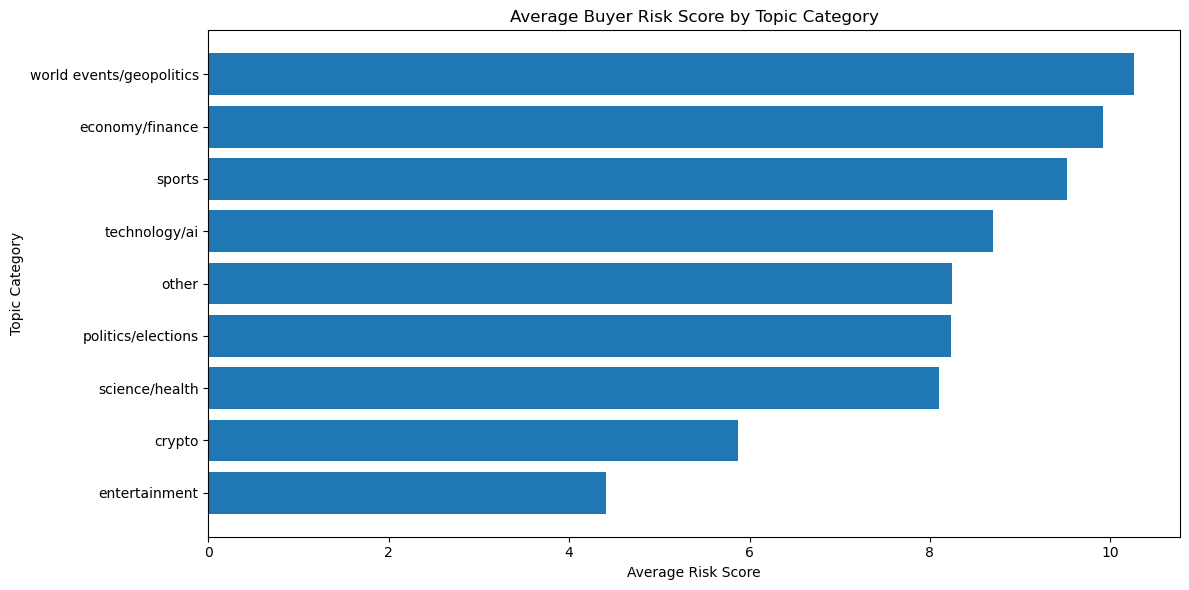

In [31]:
# Average risk score by category

plt.figure(figsize=(12, 6))

category_summary_pd_sorted = category_summary_pd.sort_values(
    "avg_risk_score",
    ascending=True
)

plt.barh(
    category_summary_pd_sorted["topic_category"],
    category_summary_pd_sorted["avg_risk_score"]
)

plt.xlabel("Average Risk Score")
plt.ylabel("Topic Category")
plt.title("Average Buyer Risk Score by Topic Category")
plt.tight_layout()
plt.show()

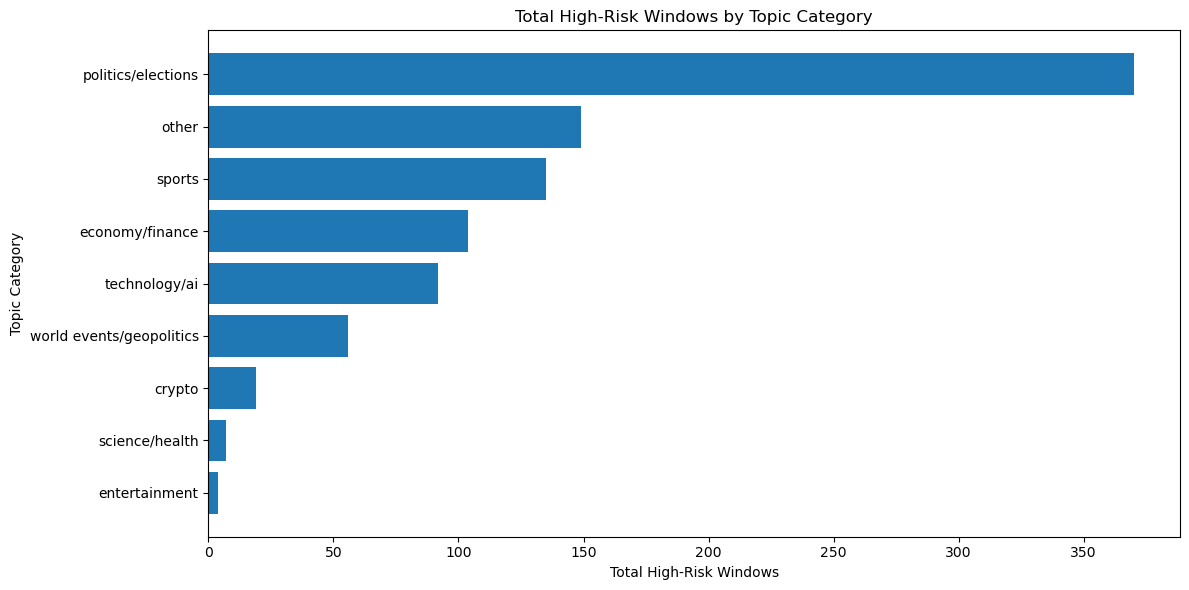

In [32]:
# Total high-risk windows by category

plt.figure(figsize=(12, 6))

category_summary_pd_sorted = category_summary_pd.sort_values(
    "total_high_risk_windows",
    ascending=True
)

plt.barh(
    category_summary_pd_sorted["topic_category"],
    category_summary_pd_sorted["total_high_risk_windows"]
)

plt.xlabel("Total High-Risk Windows")
plt.ylabel("Topic Category")
plt.title("Total High-Risk Windows by Topic Category")
plt.tight_layout()
plt.show()

In [35]:
top_markets_pd[[
    "question",
    "high_risk_window_rate",
    "avg_risk_score",
    "max_risk_score",
    "high_risk_windows",
    "window_count"
]]

,question,high_risk_window_rate,avg_risk_score,max_risk_score,high_risk_windows,window_count
0,Will the Republicans win the Oregon Senate rac...,0.000000,1.666667,5,0,24
1,Will 7-8 SpaceX Starship launches successfully...,0.000000,22.708333,40,0,24
2,Will The Bride! get the most Oscar nominations...,0.125000,21.875000,60,3,24
3,Will the New York Islanders win the 2026 NHL S...,0.000000,2.291667,5,0,24
4,Will the Indian National Congress (INC) win th...,0.000000,4.166667,5,0,24
5,Will Gold have the best performance in 2026?,0.000000,8.541667,20,0,24
6,Will the Democratic Progressive Party (DPP) wi...,0.000000,2.500000,20,0,24
7,Will Domantas Sabonis lead the NBA in assists ...,0.000000,5.000000,5,0,24
8,Another critical Cloudflare incident by March ...,0.208333,25.416667,60,5,24
9,Will Kostadin Kostadinov win the next Bulgari...,0.000000,4.583333,5,0,24


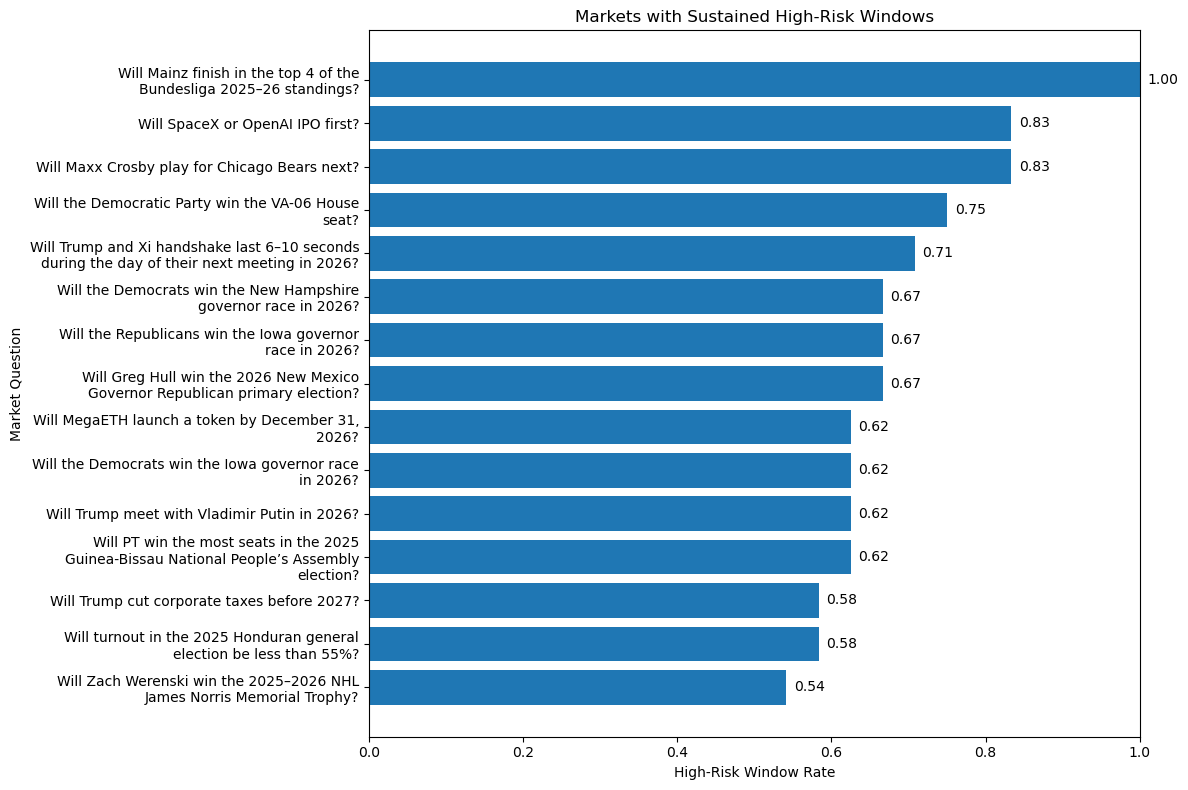

In [36]:
import textwrap
import matplotlib.pyplot as plt

plot_df = (
    df_final_market_ranking
    .filter(F.col("high_risk_window_rate") > 0)
    .orderBy(F.desc("high_risk_window_rate"), F.desc("avg_risk_score"))
    .limit(15)
    .toPandas()
)

plot_df["question_short"] = plot_df["question"].apply(
    lambda x: "\n".join(textwrap.wrap(x, width=45))
)

plot_df = plot_df.sort_values("high_risk_window_rate", ascending=True)

plt.figure(figsize=(12, 8))

plt.barh(
    plot_df["question_short"],
    plot_df["high_risk_window_rate"]
)

plt.xlabel("High-Risk Window Rate")
plt.ylabel("Market Question")
plt.title("Markets with Sustained High-Risk Windows")
plt.xlim(0, 1)

for i, value in enumerate(plot_df["high_risk_window_rate"]):
    plt.text(value + 0.01, i, f"{value:.2f}", va="center")

plt.tight_layout()
plt.show()

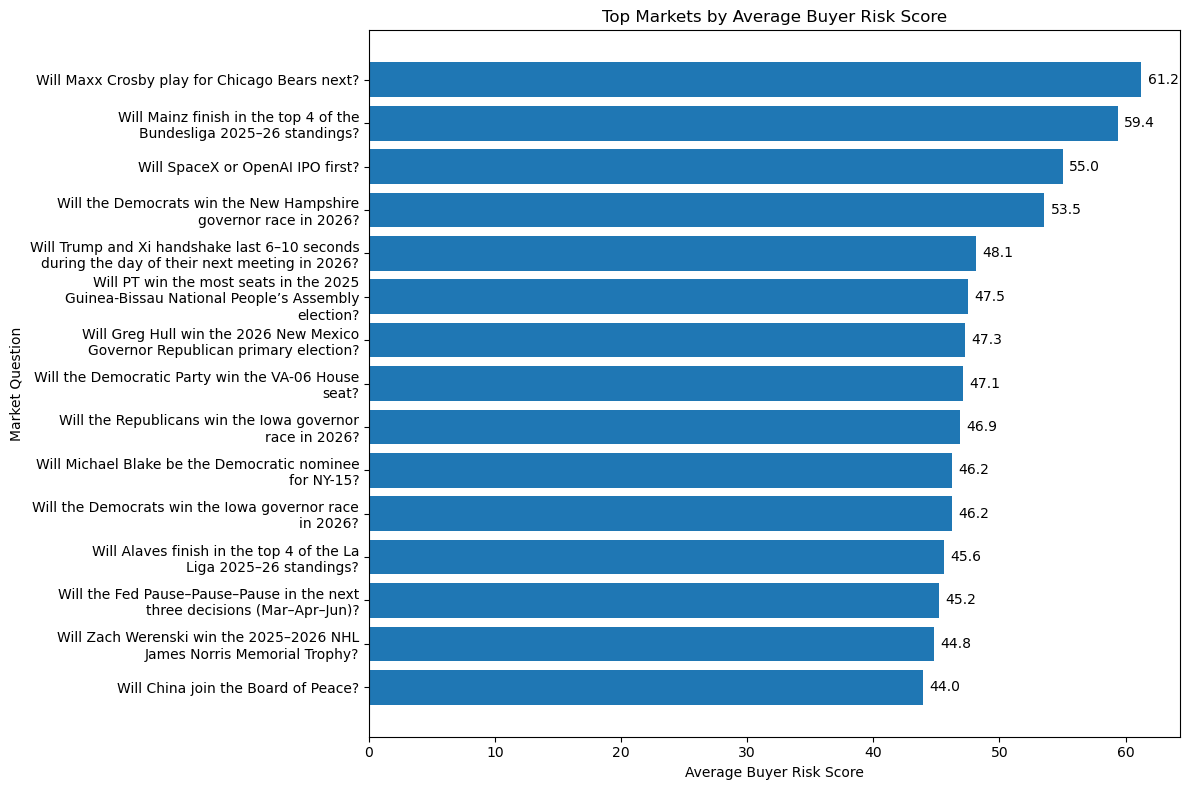

In [38]:
plot_df = (
    df_final_market_ranking
    .orderBy(F.desc("avg_risk_score"))
    .limit(15)
    .toPandas()
)

plot_df["question_short"] = plot_df["question"].apply(
    lambda x: "\n".join(textwrap.wrap(x, width=45))
)

plot_df = plot_df.sort_values("avg_risk_score", ascending=True)

plt.figure(figsize=(12, 8))

plt.barh(
    plot_df["question_short"],
    plot_df["avg_risk_score"]
)

plt.xlabel("Average Buyer Risk Score")
plt.ylabel("Market Question")
plt.title("Top Markets by Average Buyer Risk Score")

for i, value in enumerate(plot_df["avg_risk_score"]):
    plt.text(value + 0.5, i, f"{value:.1f}", va="center")

plt.tight_layout()
plt.show()

## 16. Save Final Outputs

This section saves the final outputs and a run manifest.

### Outputs saved

- final market ranking as Parquet
- final category summary as Parquet
- sample market ranking as CSV folder
- category summary as CSV folder
- `manifest.json` describing paths, run name, and saved outputs


In [34]:
# Safe final output save cell
# Uses MARKET_SCORES_EXPLAINED_PATH, which exists in this notebook.
# Avoids reading from and overwriting the same Parquet path.

import os
import shutil
import json
from datetime import datetime

def good_parquet(path):
    """Check if a Spark parquet folder looks complete."""
    if not os.path.isdir(path):
        return False
    if not os.path.exists(os.path.join(path, "_SUCCESS")):
        return False
    return any(name.endswith(".parquet") for name in os.listdir(path))

def safe_replace_parquet(df, final_path, temp_suffix="_tmp_write", partitions=8):
    """
    Write to a temp folder first, then replace the final folder.
    This prevents Spark from deleting a folder while it is still reading from it.
    """
    temp_path = final_path + temp_suffix

    if os.path.exists(temp_path):
        shutil.rmtree(temp_path)

    (
        df.repartition(partitions)
        .write
        .mode("overwrite")
        .parquet(temp_path)
    )

    if os.path.exists(final_path):
        shutil.rmtree(final_path)

    os.rename(temp_path, final_path)
    print(f"Saved: {final_path}")

# Clear Spark cache / stale file references
spark.catalog.clearCache()

os.makedirs(EXPORT_PATH, exist_ok=True)

# Rebuild final tables from the explained market scores checkpoint.
# Do NOT load from FINAL_MARKET_RANKING_PATH because that folder may be corrupted.
if good_parquet(MARKET_SCORES_EXPLAINED_PATH):
    df_market_scores_explained = spark.read.parquet(MARKET_SCORES_EXPLAINED_PATH)

elif "df_market_scores_explained" not in globals():
    raise RuntimeError(
        "df_market_scores_explained is missing and MARKET_SCORES_EXPLAINED_PATH is not available. "
        "Rerun the main risk driver / explained scores section first."
    )

df_final_market_ranking = (
    df_market_scores_explained
    .select(
        "market_id",
        "question",
        "topic_category",
        "window_count",
        "avg_risk_score",
        "max_risk_score",
        "high_risk_windows",
        "very_high_risk_windows",
        "high_risk_window_rate",
        "overall_avg_spread",
        "max_price_range",
        "avg_imbalance_score",
        "total_anomaly_count",
        "main_risk_driver"
    )
    .orderBy(
        F.desc("high_risk_window_rate"),
        F.desc("avg_risk_score"),
        F.desc("max_risk_score"),
        F.desc("total_anomaly_count")
    )
)

df_final_category_summary = (
    df_market_scores_explained
    .groupBy("topic_category")
    .agg(
        F.count("*").alias("market_count"),
        F.avg("avg_risk_score").alias("avg_risk_score"),
        F.avg("max_risk_score").alias("avg_max_risk_score"),
        F.sum("high_risk_windows").alias("total_high_risk_windows"),
        F.sum("very_high_risk_windows").alias("total_very_high_risk_windows"),
        F.avg("high_risk_window_rate").alias("avg_high_risk_window_rate"),
        F.avg("overall_avg_spread").alias("avg_spread"),
        F.avg("avg_imbalance_score").alias("avg_imbalance_score")
    )
    .orderBy(F.desc("avg_risk_score"))
)

# Safely write final Parquet outputs
safe_replace_parquet(
    df_final_market_ranking,
    FINAL_MARKET_RANKING_PATH,
    partitions=8
)

safe_replace_parquet(
    df_final_category_summary,
    FINAL_CATEGORY_SUMMARY_PATH,
    partitions=1
)

# Save CSV outputs using Spark instead of toPandas
market_csv_path = os.path.join(EXPORT_PATH, "final_market_ranking_sample_csv")
category_csv_path = os.path.join(EXPORT_PATH, "final_category_summary_csv")

for p in [market_csv_path, category_csv_path]:
    if os.path.exists(p):
        shutil.rmtree(p)

(
    df_final_market_ranking
    .limit(1000)
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(market_csv_path)
)

(
    df_final_category_summary
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(category_csv_path)
)

manifest = {
    "run_name": RUN_NAME,
    "created_at": datetime.now().isoformat(),
    "labels_path": LABELS_PATH,
    "orderbook_path": ORDERBOOK_PATH,
    "run_path": RUN_PATH,
    "silver_path": SILVER_PATH,
    "gold_path": GOLD_PATH,
    "export_path": EXPORT_PATH,
    "force_rebuild": FORCE_REBUILD,
    "saved_tables": {
        "ob_labeled_clean": OB_LABELED_CLEAN_PATH,
        "market_window_features": FEATURES_PATH,
        "scored_market_windows": SCORED_WINDOWS_PATH,
        "market_scores_explained": MARKET_SCORES_EXPLAINED_PATH,
        "final_market_ranking": FINAL_MARKET_RANKING_PATH,
        "final_category_summary": FINAL_CATEGORY_SUMMARY_PATH,
        "final_market_ranking_sample_csv_folder": market_csv_path,
        "final_category_summary_csv_folder": category_csv_path,
    },
    "notes": "Resumable MVP rule-based buyer risk scoring pipeline using 1-hour market windows."
}

with open(os.path.join(RUN_PATH, "manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2)

print("Outputs saved.")
print("Run path:", RUN_PATH)
print("Export path:", EXPORT_PATH)

checkpoint_status()

Saved: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/final_market_ranking
Saved: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/gold/final_category_summary
Outputs saved.
Run path: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp
Export path: /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/exports
ob_labeled_clean             FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/silver/ob_labeled_clean
market_activity              FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2026_03_06_mvp/silver/market_activity
active_markets               FOUND - /home2/msds2026/ktorres/bdcc2026/Lab 1/git/PolyMarket_BigData/polymarket_outputs/orderbook_2

# Market Manipulation Detection

## Higher Resolution Classification  
- Polymarket Questions involve a wide range topic categories from politics, to entertainment, to memes etc. In order to observe how the market behaves across different topics, we will attempt to classify each question using NLP.
- Here we attempt to categorize the markets using hugging face transformer with facebook model facebook/bart-large-mnli" for a zero-shot classification
- this helps to study the behavior of the markets by category/topic and if underlying behaviors emerge from those observations
- we set the categories and the transformer then finds the probabilities for each topic to match each classifier
- topic discovery was conducted in a seperate notebook using NMF Topic Modelling Approach
- NOTE: RUN ONLY ON JOJIE CPU. Transformer labeling is about half a minute per row

View Here to know more about Transformers for Zero-Shot Classification https://huggingface.co/docs/
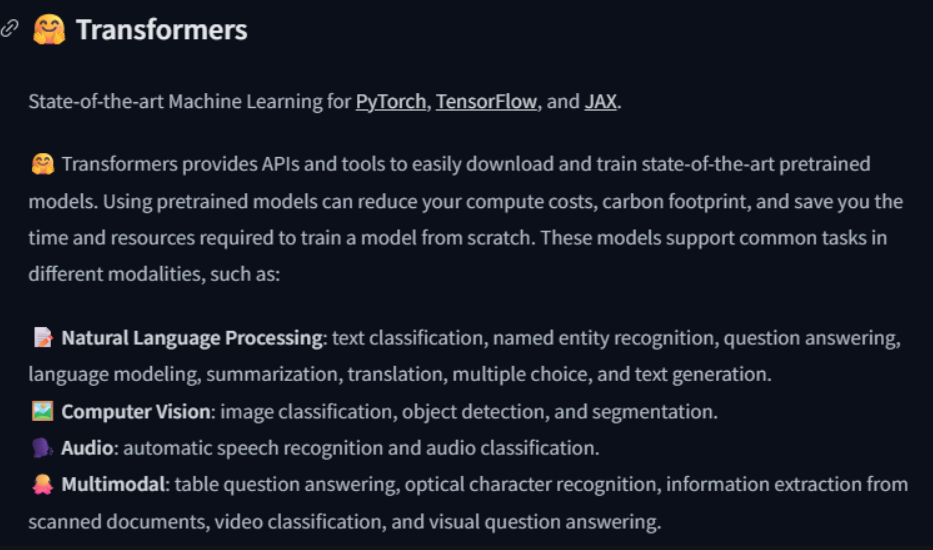

In [ ]:
import polars as pl
import pandas as pd
from transformers import pipeline

# 1) Load question lookup
# labels = pl.read_parquet("slt3a/Lab 1/data/market_targets.parquet")
labels = pl.read_parquet("/mnt/data/public/polymarket/labels/market_targets.parquet")
labels_lu = (
    labels
    .select(["condition_id", "question"])
    .unique(subset=["condition_id"])
)

# 2) Attach question text to your filtered table
filtered_with_q = (
    filtered
    .join(labels_lu, on="condition_id", how="left")
    .filter(pl.col("question").is_not_null())
)

# 3) Convert to pandas for easy iteration
pdf = filtered_with_q.select([
    "condition_id", "question", "volume", "liquidity", "target"
]).to_pandas()

# Optional: dedupe repeated questions per condition_id before classifying
pdf_unique = pdf.drop_duplicates(subset=["condition_id"]).copy() # RUNS ENTIRE DATASET
# pdf_unique = pdf.drop_duplicates(subset=["condition_id"]).head(500).copy() # TEST RUN on smaller dataset
pdf_unique = (
    pdf
    .drop_duplicates(subset=["condition_id"])
    .iloc[2100:] # SET LIMIT HERE
    .copy()
)
# 4) Zero-shot classifier
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0 # 0 to use GPU and -1 for CPU. GPU only works in Jojie
)

candidate_labels = ["politics", "entertainment","sports", "crypto", "economy", "world events", "culture", "science", "finance", "others"]

# # 5) Classify (top label + score)
# def classify_question(q):
#     r = classifier(q, candidate_labels=candidate_labels, multi_label=False)
#     return pd.Series({
#         "pred_label": r["labels"][0],
#         "pred_score": r["scores"][0]
#     })
# 5) Classify (top 3 labels + scores)
def classify_question(q):
    r = classifier(str(q), candidate_labels=candidate_labels, multi_label=False)
    return pd.Series({
        "top1_label": r["labels"][0], "top1_score": r["scores"][0],
        "top2_label": r["labels"][1], "top2_score": r["scores"][1],
        "top3_label": r["labels"][2], "top3_score": r["scores"][2],
    })

top3 = pdf_unique["question"].apply(classify_question)
pdf_unique = pd.concat([pdf_unique, top3], axis=1)

out = pdf.merge(
    pdf_unique[[
        "condition_id",
        "top1_label", "top1_score",
        "top2_label", "top2_score",
        "top3_label", "top3_score"
    ]],
    on="condition_id",
    how="left"
)

from pathlib import Path
import polars as pl

# Create ./data in current working directory
data_dir = Path.cwd() / "data"
data_dir.mkdir(parents=True, exist_ok=True)

save_path = data_dir / "market_targets_classified_all.parquet"

# If out is already a polars DataFrame:
out.write_parquet(save_path)

# If out is pandas DataFrame instead, use this line instead:
# pl.from_pandas(out).write_parquet(save_path)

print("Saved to:", save_path.resolve())

Loading and Observing Classified Markets

In [162]:
import json, polars as pl
data_dir = Path.cwd() / "data"
# Load Data
# path = "slt3a/Lab 1/data/market_targets_classified_all.parquet"
path = data_dir/"market_targets_classified_all.parquet"

# Polar Dataframe Version
df_market_class = pl.scan_parquet(path)
# df_market_class.limit(10).collect().to_pandas()
# df_market_class.collect().to_pandas()

# Remove exact duplicate rows
df_market_class_dedup = (
    pl.scan_parquet(path)
    .unique(subset=["condition_id"], keep="first")
)
# materialize if needed
df_market_class_dedup.collect().head(5).to_pandas()

,condition_id,question,volume,liquidity,target,top1_label,top1_score,top2_label,top2_score,top3_label,top3_score
0,0x39676b9161ea372b38115423a5de8f700f1888c35dd0...,Will Alphabet be the largest company in the wo...,142016.921467,75488.27280,NaN,world events,0.337841,economy,0.185653,others,0.164739
1,0xd73eaca0ff89411ac245891bb437f47f02b576801203...,Will Nottm Forest be relegated from the Englis...,33004.680138,10130.32540,NaN,sports,0.296277,others,0.186701,economy,0.110509
2,0xb3fff2cd8da52774a2c06a09535a5fb81fc9f65add5a...,Will Elon Musk post 1320-1359 tweets in March ...,428264.892748,25426.60428,NaN,others,0.335255,entertainment,0.116973,culture,0.113664
3,0x222b78a4b51e49a79996d02878ae8309baf2c2ed38fb...,"Will the price of Bitcoin be above $62,000 on ...",36628.670811,20576.14863,NaN,crypto,0.759423,finance,0.077287,others,0.050836
4,0x306bbce53f9a77906b9a928d52728bdee2e48f3354d1...,Will Scott Jensen win the 2026 Minnesota Gover...,47415.668218,18763.42602,NaN,politics,0.616929,others,0.110402,culture,0.061599


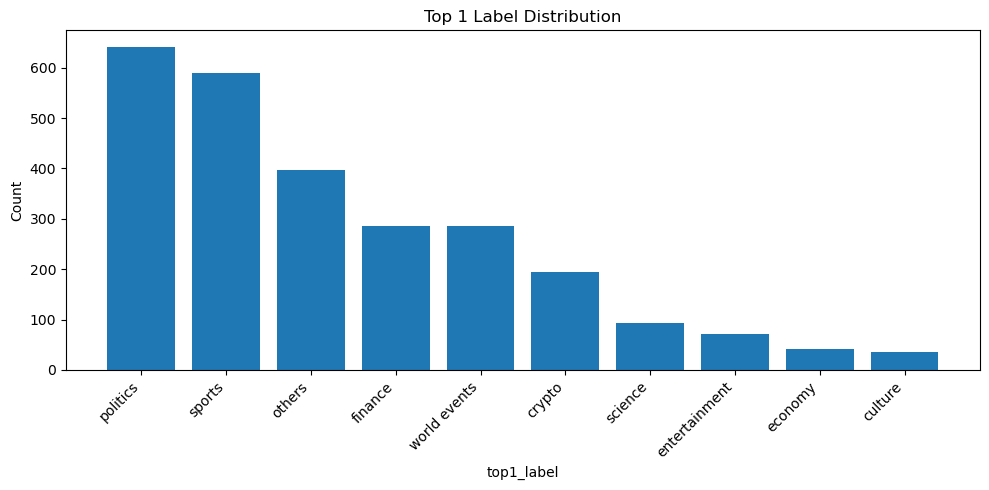

In [164]:
import polars as pl
import matplotlib.pyplot as plt

# Materialize once
df = df_market_class_dedup.collect()

col = "top1_label"
if col not in df.columns:
    raise ValueError(f"Column '{col}' not found. Available: {df.columns}")

vc = (
    df.select(pl.col(col).drop_nulls().value_counts())
    .unnest(col)
    .sort("count", descending=True)
    .head(15)  # top 15 categories
)

labels = vc[col].to_list()
counts = vc["count"].to_list()

plt.figure(figsize=(10, 5))
plt.bar(labels, counts)
plt.title("Top 1 Label Distribution")
plt.xlabel("top1_label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Observations**  
After running the transformer classifiers, we see politics and sports being the top contents of the polymarket topics questions. The other following topics include finance, world events, and crypto.

The 2nd and 3rd rank labels do show higher "other" classification instead of more meaningful labels. Manually Observing the rows and data labels, the top 1 labels should be enough for our market category analysis.

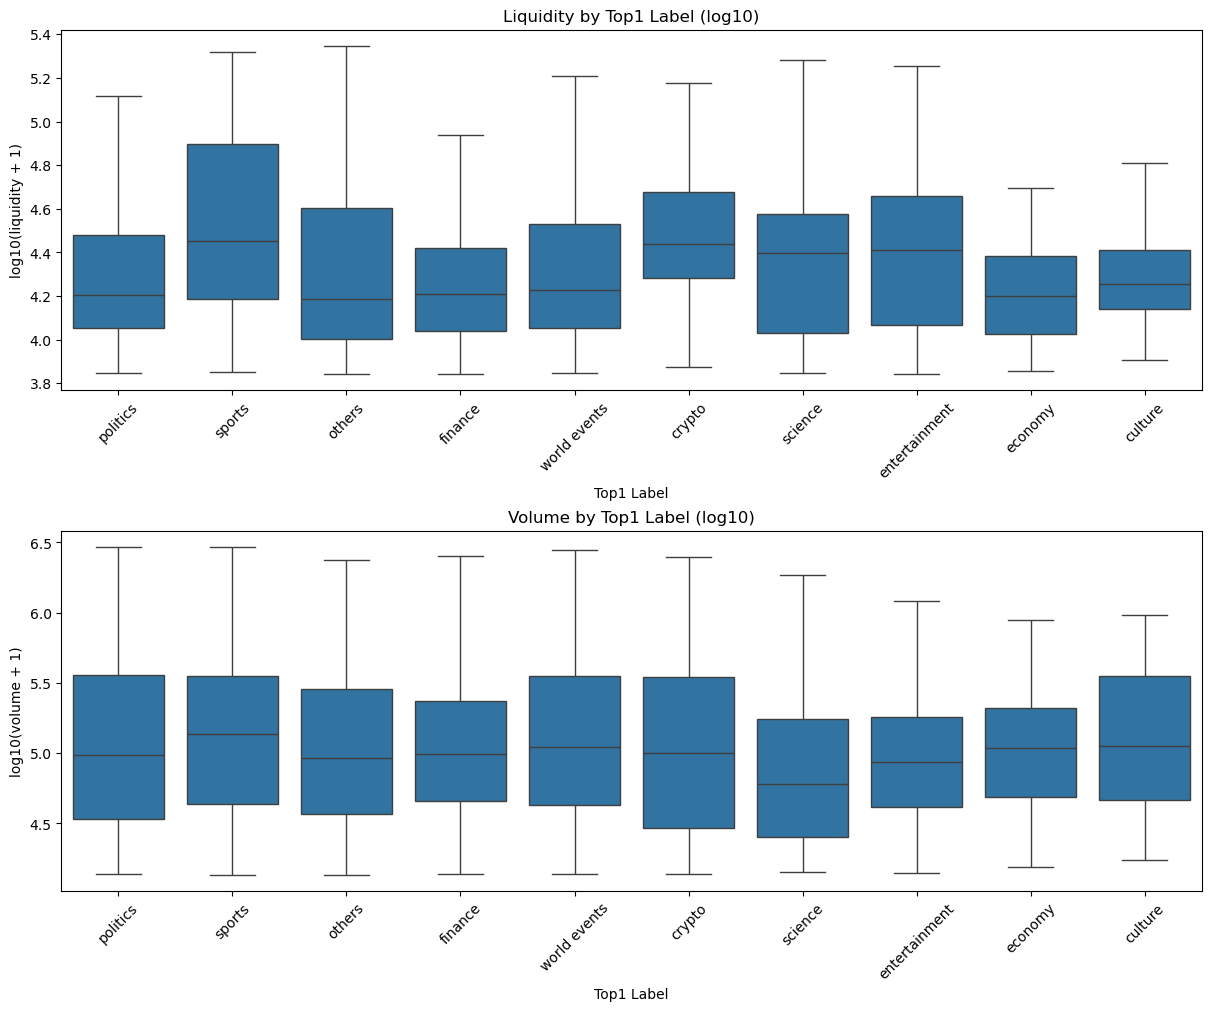

In [165]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Materialize
df = df_market_class_dedup.collect()

# Keep needed columns + clean nulls
plot_df = (
    df.select(["top1_label", "liquidity", "volume"])
      .drop_nulls()
      .to_pandas()
)

# Optional: keep only top N labels for readability
top_n = 12
top_labels = plot_df["top1_label"].value_counts().head(top_n).index
plot_df = plot_df[plot_df["top1_label"].isin(top_labels)].copy()

# Optional: log transform if highly skewed
plot_df["liquidity_log10"] = np.log10(plot_df["liquidity"] + 1)
plot_df["volume_log10"] = np.log10(plot_df["volume"] + 1)

# Order labels by frequency
order = plot_df["top1_label"].value_counts().index.tolist()

fig, axes = plt.subplots(2, 1, figsize=(12, 10), constrained_layout=True)

sns.boxplot(data=plot_df, x="top1_label", y="liquidity_log10", order=order, ax=axes[0], showfliers=False)
axes[0].set_title("Liquidity by Top1 Label (log10)")
axes[0].set_xlabel("Top1 Label")
axes[0].set_ylabel("log10(liquidity + 1)")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=plot_df, x="top1_label", y="volume_log10", order=order, ax=axes[1], showfliers=False)
axes[1].set_title("Volume by Top1 Label (log10)")
axes[1].set_xlabel("Top1 Label")
axes[1].set_ylabel("log10(volume + 1)")
axes[1].tick_params(axis="x", rotation=45)

plt.show()


**Observation**  
Using the modified labels and observing thheir liquidity (active orders) and volume (total completed transactions) we see sports and crypto having the largest amounts of active orders in the book. Volume wise we see the distriubtion is a bit more even but with politics, sports, world events, and crypto having the higher upper spread of traded volume.

## Detecting Market Pumps
Pump-and-dump schemes occur when people work together to trick investors into believing a security is worth more than it is, often by spreading false or exaggerated claims. This creates fake demand, pushes prices up, and harms investors who trust the wrong information. Once prices are high from the manipulation, investors begin to mass sell their inventory at high prices in order to secure their profits. The sudden increase in supply then causes the price to sharply drop securing profits for the manipulators and a low value share to users.

We will be using Trade Orders to see which markets have high likelihoods for pump and dump scenarios. We only observe the transanction executions 

For Pump and Dump we will be following the research of "To the moon: defining and detecting cryptocurrency pump-and-dumpsm" by Josh Kamps1 and Bennett Kleinberg. Who have laid down the methods to detect pump and dump movements in cryptocurrency.
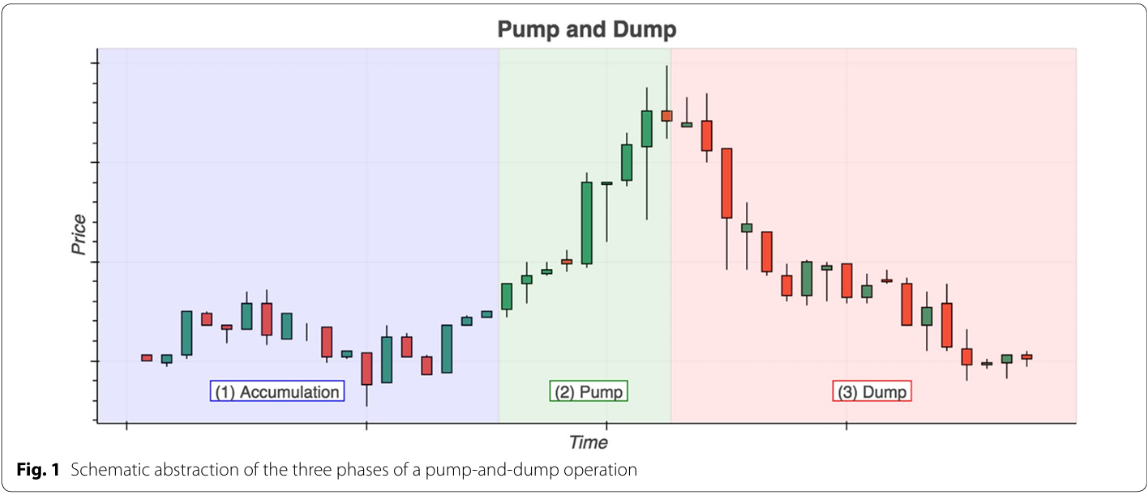

The Study uses thresholds to detect these anomalies such as sudden price and volume increases within a given time window. The study follows multiple metrics to detect pumps and pump-and-dumps seperately controlled by 3 main kinds of parameters:

Initial parameters
- Purpose: Start with a relatively weak/sensitive baseline to detect many possible pump-and-dump events.
- Estimation window: 12 hours
- Volume increase threshold: 25%
- Price increase threshold: 3%

Strict parameters
- Purpose: Reduce false positives by requiring stronger evidence of abnormal activity.
- Estimation window: 24 hours
- Volume increase threshold: 400%
- Price increase threshold: 50%

Balanced parameters
- Purpose: Find a middle ground between the sensitive initial setting and the strict setting.
- Estimation window: 12 hours
- Volume increase threshold: 300%
- Price increase threshold: 5%

| Metric used in score | Plain meaning | How much it can affect score |
|---|---|---|
| `pump_flag_count` | How many times the market showed a pump-like pattern (price and volume spike together). | Adds `10` points per flagged window (can add up fast). |
| `pump_and_dump_flag_count` | How many times a pump was followed by a drop (dump-like behavior). | Adds `25` points per flagged window (strongest signal). |
| `max_price_ratio` term | How extreme the biggest relative price spike was vs your threshold. | Up to `20` points. |
| `max_price_abs_change` term | How large the biggest absolute price jump was vs your threshold. | Up to `20` points. |
| `max_volume_ratio` term | How extreme the biggest volume spike was vs your threshold. | Up to `20` points. |

| Final interpretation |
|---|
| The model adds all parts, then caps the total to `0–100` as `pump_and_dump_manipulation_score`. |
| Risk label is then assigned: `high (>=70)`, `medium (>=40)`, `low (>0)`, `none (=0)`. |



In [142]:
import polars as pl
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go


def calculate_and_rank_manipulation_scores(
    targets_path: str,
    trades_path: str,
    selected_profile: str = "Balanced",
    initial_params: dict | None = None,
    balanced_params: dict | None = None,
    strict_params: dict | None = None,
    p_low: float = 90.0,
    p_high: float = 99.9,
    top_n_windows: int = 50,
):
    """
    Function 1:
    - Computes market manipulation scores
    - Ranks markets
    - Returns scored windows + ranked market table + top suspicious windows

    The 3 settings (Initial, Balanced, Strict) are explicit inputs.
    """

    # Default settings
    default_initial = {
        "WINDOW": "1m",
        "BASELINE_WINDOWS": 720,
        "PRICE_INCREASE_PCT": 0.03,
        "ABS_PRICE_INCREASE": 0.01,
        "VOLUME_MULTIPLIER": 1.25,
        "DUMP_LOOKAHEAD": 60,
        "DUMP_DROP_PCT": 0.02,
        "ABS_DUMP_DROP": 0.01,
    }
    default_balanced = {
        "WINDOW": "1m",
        "BASELINE_WINDOWS": 720,
        "PRICE_INCREASE_PCT": 0.05,
        "ABS_PRICE_INCREASE": 0.03,
        "VOLUME_MULTIPLIER": 3.00,
        "DUMP_LOOKAHEAD": 90,
        "DUMP_DROP_PCT": 0.03,
        "ABS_DUMP_DROP": 0.02,
    }
    default_strict = {
        "WINDOW": "1m",
        "BASELINE_WINDOWS": 1440,
        "PRICE_INCREASE_PCT": 0.5,
        "ABS_PRICE_INCREASE": 0.4,
        "VOLUME_MULTIPLIER": 4.00,
        "DUMP_LOOKAHEAD": 120,
        "DUMP_DROP_PCT": 0.05,
        "ABS_DUMP_DROP": 0.03,
    }

    initial = initial_params or default_initial
    balanced = balanced_params or default_balanced
    strict = strict_params or default_strict

    settings_map = {"Initial": initial, "Balanced": balanced, "Strict": strict}
    if selected_profile not in settings_map:
        raise ValueError("selected_profile must be one of: Initial, Balanced, Strict")

    cfg = settings_map[selected_profile]

    targets = pl.scan_parquet(targets_path)
    trades = pl.scan_parquet(trades_path)

    all_markets_lf = (
        targets
        .with_columns([
            pl.col("condition_id").cast(pl.Utf8),
            pl.col("liquidity").cast(pl.Float64),
            pl.col("volume").cast(pl.Float64),
            pl.when((pl.col("closed") == True) & (pl.col("target").is_not_null()))
            .then(pl.lit("resolved"))
            .otherwise(pl.lit("unresolved"))
            .alias("market_status")
        ])
    )

    # Only Volume
    bounds = (
        all_markets_lf
        .select([
            pl.col("volume").quantile(p_low / 100).alias("vol_min"),
            pl.col("volume").quantile(p_high / 100).alias("vol_max"),
        ])
        .collect()
        .to_dicts()[0]
    )
    vol_min, vol_max = bounds["vol_min"], bounds["vol_max"]

    markets_filtered_lf = all_markets_lf.filter(
        pl.col("volume").is_between(vol_min, vol_max, closed="both")
    )

    trade_cols = trades.collect_schema().names()

    def first_existing(candidates, cols):
        for c in candidates:
            if c in cols:
                return c
        raise ValueError(f"None of these columns found: {candidates}")

    time_col = first_existing(["timestamp", "timestamp_received", "created_at", "time"], trade_cols)
    price_col = first_existing(["price", "trade_price", "last_price"], trade_cols)
    size_col = first_existing(["size", "amount", "shares", "trade_size"], trade_cols)

    ts_sample = trades.select(pl.col(time_col).drop_nulls().first()).collect().item()
    if isinstance(ts_sample, (int, float)):
        ts_max = trades.select(pl.col(time_col).drop_nulls().max()).collect().item()
        event_time_expr = pl.from_epoch(pl.col(time_col), time_unit="ms" if ts_max > 1_000_000_000_000 else "s")
    elif isinstance(ts_sample, str):
        event_time_expr = pl.col(time_col).str.to_datetime(strict=False)
    else:
        event_time_expr = pl.col(time_col).cast(pl.Datetime)

    filtered_market_ids_lf = markets_filtered_lf.select("condition_id").unique()

    trades_filtered_lf = (
        trades
        .with_columns([
            pl.col("condition_id").cast(pl.Utf8),
            event_time_expr.alias("event_time"),
            pl.col(price_col).cast(pl.Float64).alias("trade_price"),
            pl.col(size_col).cast(pl.Float64).alias("trade_size"),
        ])
        .join(filtered_market_ids_lf, on="condition_id", how="inner")
        .filter(
            pl.col("event_time").is_not_null() &
            pl.col("trade_price").is_not_null() &
            pl.col("trade_size").is_not_null()
        )
        .with_columns((pl.col("trade_price") * pl.col("trade_size")).alias("dollar_volume"))
    )

    group_keys = ["condition_id"]
    if "outcome" in trade_cols:
        group_keys.append("outcome")
    elif "token_id" in trade_cols:
        group_keys.append("token_id")

    candles_lf = (
        trades_filtered_lf
        .sort(group_keys + ["event_time"])
        .group_by_dynamic(
            index_column="event_time",
            every=cfg["WINDOW"],
            group_by=group_keys
        )
        .agg([
            pl.first("trade_price").alias("open"),
            pl.max("trade_price").alias("high"),
            pl.min("trade_price").alias("low"),
            pl.last("trade_price").alias("close"),
            pl.sum("trade_size").alias("trade_volume"),
            pl.sum("dollar_volume").alias("dollar_volume"),
            pl.len().alias("trade_count"),
        ])
        .sort(group_keys + ["event_time"])
    )

    future_min_expr = pl.min_horizontal([
        pl.col("close").shift(-i).over(group_keys)
        for i in range(1, cfg["DUMP_LOOKAHEAD"] + 1)
    ])

    scored_windows_lf = (
        candles_lf
        .with_columns([
            pl.col("close")
            .shift(1)
            .rolling_mean(window_size=cfg["BASELINE_WINDOWS"], min_samples=3)
            .over(group_keys)
            .alias("baseline_close"),
            pl.col("trade_volume")
            .shift(1)
            .rolling_mean(window_size=cfg["BASELINE_WINDOWS"], min_samples=3)
            .over(group_keys)
            .alias("baseline_volume"),
        ])
        .with_columns([
            pl.when(pl.col("baseline_close") > 0).then(pl.col("high") / pl.col("baseline_close")).otherwise(None).alias("price_ratio"),
            (pl.col("high") - pl.col("baseline_close")).alias("price_abs_change"),
            pl.when(pl.col("baseline_volume") > 0).then(pl.col("trade_volume") / pl.col("baseline_volume")).otherwise(None).alias("volume_ratio"),
        ])
        .with_columns([
            (
                (pl.col("price_ratio") >= (1 + cfg["PRICE_INCREASE_PCT"])) |
                (pl.col("price_abs_change") >= cfg["ABS_PRICE_INCREASE"])
            ).alias("price_anomaly"),
            (pl.col("volume_ratio") >= cfg["VOLUME_MULTIPLIER"]).alias("volume_anomaly"),
        ])
        .with_columns([
            (pl.col("price_anomaly") & pl.col("volume_anomaly")).alias("pump_flag"),
            future_min_expr.alias("future_min_close"),
        ])
        .with_columns([
            (
                pl.col("pump_flag") &
                (
                    (pl.col("future_min_close") <= pl.col("high") * (1 - cfg["DUMP_DROP_PCT"])) |
                    ((pl.col("high") - pl.col("future_min_close")) >= cfg["ABS_DUMP_DROP"])
                )
            ).alias("pump_and_dump_flag")
        ])
    )

    market_pnd_scores_lf = (
        scored_windows_lf
        .group_by("condition_id")
        .agg([
            pl.len().alias("num_trade_windows"),
            pl.col("pump_flag").cast(pl.Int64).sum().alias("pump_flag_count"),
            pl.col("pump_and_dump_flag").cast(pl.Int64).sum().alias("pump_and_dump_flag_count"),
            pl.col("price_ratio").max().alias("max_price_ratio"),
            pl.col("price_abs_change").max().alias("max_price_abs_change"),
            pl.col("volume_ratio").max().alias("max_volume_ratio"),
            pl.col("trade_volume").sum().alias("window_trade_volume"),
            pl.col("dollar_volume").sum().alias("window_dollar_volume"),
            pl.col("trade_count").sum().alias("window_trade_count"),
        ])
        .with_columns([
            (
                10 * pl.col("pump_flag_count") +
                25 * pl.col("pump_and_dump_flag_count") +
                20 * ((pl.col("max_price_ratio") - (1 + cfg["PRICE_INCREASE_PCT"])) / cfg["PRICE_INCREASE_PCT"]).clip(0, 1) +
                20 * (pl.col("max_price_abs_change") / cfg["ABS_PRICE_INCREASE"]).clip(0, 1) +
                20 * ((pl.col("max_volume_ratio") - cfg["VOLUME_MULTIPLIER"]) / cfg["VOLUME_MULTIPLIER"]).clip(0, 1)
            ).fill_nan(0).fill_null(0).clip(0, 100).alias("pump_and_dump_manipulation_score")
        ])
        .with_columns([
            pl.when(pl.col("pump_and_dump_manipulation_score") >= 70).then(pl.lit("high"))
            .when(pl.col("pump_and_dump_manipulation_score") >= 40).then(pl.lit("medium"))
            .when(pl.col("pump_and_dump_manipulation_score") > 0).then(pl.lit("low"))
            .otherwise(pl.lit("none"))
            .alias("pump_and_dump_risk_level")
        ])
    )

    final_market_scores_lf = (
        markets_filtered_lf
        .join(market_pnd_scores_lf, on="condition_id", how="left")
        .with_columns([
            pl.col("num_trade_windows").fill_null(0),
            pl.col("pump_flag_count").fill_null(0),
            pl.col("pump_and_dump_flag_count").fill_null(0),
            pl.col("max_price_ratio").fill_null(0),
            pl.col("max_price_abs_change").fill_null(0),
            pl.col("max_volume_ratio").fill_null(0),
            pl.col("window_trade_volume").fill_null(0),
            pl.col("window_dollar_volume").fill_null(0),
            pl.col("window_trade_count").fill_null(0),
            pl.col("pump_and_dump_manipulation_score").fill_null(0),
            pl.col("pump_and_dump_risk_level").fill_null("none"),
        ])
        .sort("pump_and_dump_manipulation_score", descending=True)
    )

    df_market_scores = final_market_scores_lf.collect().to_pandas()


    # --- manipulation coverage summary ---
    total_markets = len(df_market_scores)
    likely_mask = df_market_scores["pump_and_dump_risk_level"].isin(["low", "medium", "high"])
    likely_manipulated_markets = int(likely_mask.sum())
    likely_pct = (likely_manipulated_markets / total_markets * 100) if total_markets else 0.0

    print(
        f"Likely manipulated markets: {likely_manipulated_markets:,} / {total_markets:,} "
        f"({likely_pct:.2f}%)"
    )

    top_windows = (
        scored_windows_lf
        .filter(pl.col("price_ratio").is_not_null() & pl.col("volume_ratio").is_not_null())
        .with_columns([
            (
                pl.col("price_ratio").fill_null(0) +
                pl.col("volume_ratio").fill_null(0) +
                (pl.col("price_abs_change").fill_null(0) * 100)
            ).alias("suspicion_sort_score")
        ])
        .sort("suspicion_sort_score", descending=True)
        .limit(top_n_windows)
        .collect()
        .to_pandas()
    )

    return {
        "settings_name": selected_profile,
        "settings": cfg,
        "group_keys": group_keys,
        "df_market_scores": df_market_scores,
        "scored_windows_lf": scored_windows_lf,
        "top_windows": top_windows,
        "volume_bounds": {"vol_min": vol_min, "vol_max": vol_max},
        "summary": {"total_markets": total_markets, "likely_manipulated_markets": likely_manipulated_markets, "likely_manipulated_pct": likely_pct,},
    }
def view_individual_marks_with_top_scores(
    result: dict,
    rank_overall: int = 0,   # 0 = highest score market
):
    """
    Function 2 (updated):
    - Picks one market purely by overall rank of manipulation score
    - Shows detailed 3-panel plot
    - Returns selected market info + flagged windows
    """
    df_market_scores = result["df_market_scores"]
    scored_windows_lf = result["scored_windows_lf"]
    cfg = result["settings"]

    ranked_markets = (
        df_market_scores
        .sort_values("pump_and_dump_manipulation_score", ascending=False)
        .reset_index(drop=True)
    )

    if len(ranked_markets) == 0:
        raise ValueError("No ranked markets found.")
    if rank_overall >= len(ranked_markets):
        raise ValueError(f"rank_overall out of range. Max index: {len(ranked_markets)-1}")

    selected_market_row = ranked_markets.loc[rank_overall]
    selected_condition_id = selected_market_row["condition_id"]

    question_candidates = ["question", "title", "market_title", "name"]
    question_col = next((c for c in question_candidates if c in ranked_markets.columns), None)
    selected_question = (
        selected_market_row[question_col]
        if question_col is not None and pd.notna(selected_market_row[question_col])
        else "Question unavailable"
    )

    market_windows_pdf = (
        scored_windows_lf
        .filter(pl.col("condition_id") == selected_condition_id)
        .sort("event_time")
        .collect()
        .to_pandas()
    )
    market_windows_pdf["event_time"] = pd.to_datetime(market_windows_pdf["event_time"])

    group_cols_available = [c for c in ["outcome", "token_id"] if c in market_windows_pdf.columns]
    if group_cols_available:
        group_col = group_cols_available[0]
        summary = (
            market_windows_pdf.groupby(group_col)
            .agg(
                num_windows=("event_time", "count"),
                pump_flags=("pump_flag", "sum"),
                pump_and_dump_flags=("pump_and_dump_flag", "sum"),
                max_price_ratio=("price_ratio", "max"),
                max_price_abs_change=("price_abs_change", "max"),
                max_volume_ratio=("volume_ratio", "max"),
            )
            .reset_index()
            .sort_values(
                ["pump_and_dump_flags", "pump_flags", "max_price_ratio", "max_price_abs_change", "max_volume_ratio"],
                ascending=False
            )
        )
        selected_group_value = summary.iloc[0][group_col]
        plot_df = market_windows_pdf[market_windows_pdf[group_col] == selected_group_value].copy()
        plot_group_label = f"{group_col}: {selected_group_value}"
    else:
        plot_df = market_windows_pdf.copy()
        plot_group_label = "All trades"

    plot_df = plot_df.sort_values("event_time")
    pump_points = plot_df[plot_df["pump_flag"] == True].copy()
    pnd_points = plot_df[plot_df["pump_and_dump_flag"] == True].copy()

    fig = make_subplots(
        rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.08,
        subplot_titles=["Price Movement", "Trade Volume", "Anomaly Ratios vs Thresholds"]
    )

    fig.add_trace(go.Scatter(x=plot_df["event_time"], y=plot_df["close"], mode="lines+markers", name="Close Price"), row=1, col=1)
    if "baseline_close" in plot_df.columns:
        fig.add_trace(go.Scatter(x=plot_df["event_time"], y=plot_df["baseline_close"], mode="lines", name="Baseline Close", line=dict(dash="dash")), row=1, col=1)
    fig.add_trace(go.Scatter(x=pump_points["event_time"], y=pump_points["high"], mode="markers", name="Pump Flag", marker=dict(symbol="triangle-up", size=11)), row=1, col=1)
    fig.add_trace(go.Scatter(x=pnd_points["event_time"], y=pnd_points["high"], mode="markers", name="Pump-and-Dump Flag", marker=dict(symbol="x", size=12)), row=1, col=1)

    # fig.add_trace(go.Bar(x=plot_df["event_time"], y=plot_df["trade_volume"], name="Trade Volume", opacity=0.65), row=2, col=1)
    fig.add_trace(go.Scatter(x=plot_df["event_time"],y=plot_df["trade_volume"],mode="lines",name="Trade Volume (Line)",line=dict(width=2), hovertemplate="Time=%{x}<br>Trade Volume=%{y:.2f}<extra></extra>"), row=2,col=1)

    if "baseline_volume" in plot_df.columns:
        fig.add_trace(go.Scatter(x=plot_df["event_time"], y=plot_df["baseline_volume"], mode="lines", name="Baseline Volume", line=dict(dash="dash")), row=2, col=1)
    fig.add_trace(go.Scatter(x=pump_points["event_time"], y=pump_points["trade_volume"], mode="markers", name="Pump Volume Flag", marker=dict(symbol="triangle-up", size=11)), row=2, col=1)
    fig.add_trace(go.Scatter(x=pnd_points["event_time"], y=pnd_points["trade_volume"], mode="markers", name="P&D Volume Flag", marker=dict(symbol="x", size=12)), row=2, col=1)

    fig.add_trace(go.Scatter(x=plot_df["event_time"], y=plot_df["price_ratio"], mode="lines+markers", name="Price Ratio"), row=3, col=1)
    fig.add_trace(go.Scatter(x=plot_df["event_time"], y=plot_df["volume_ratio"], mode="lines+markers", name="Volume Ratio"), row=3, col=1)

    fig.add_hline(y=1 + cfg["PRICE_INCREASE_PCT"], line_dash="dash", annotation_text=f"Price Threshold: {1 + cfg['PRICE_INCREASE_PCT']:.2f}", row=3, col=1)
    fig.add_hline(y=cfg["VOLUME_MULTIPLIER"], line_dash="dot", annotation_text=f"Volume Threshold: {cfg['VOLUME_MULTIPLIER']:.2f}", row=3, col=1)

    fig.update_layout(
        height=850,
        width=1000,
        hovermode="x unified",
        title=dict(
            text=(
                f"Pump-and-Dump Visualization | Overall Rank #{rank_overall + 1}<br>"
                f"<sup>{selected_question}</sup><br><sup>{plot_group_label}</sup>"
            ),
            x=0.5,
            # pad=dict(b=28)
        ),
        margin=dict(t=160),
        legend=dict(orientation="h", yanchor="bottom", y=-0.22, xanchor="center", x=0.5),
    )
    fig.update_yaxes(title_text="Price", row=1, col=1)
    fig.update_yaxes(title_text="Trade Volume", row=2, col=1)
    fig.update_yaxes(title_text="Ratio vs Baseline", row=3, col=1)
    fig.update_xaxes(title_text="Time",title_standoff=0.1, row=3, col=1)
    fig.update_layout(legend=dict(orientation="h", yanchor="top", y=-0.18, xanchor="center", x=0.5), margin=dict(b=120))

    fig.show()

    flagged_windows = plot_df[(plot_df["pump_flag"] == True) | (plot_df["pump_and_dump_flag"] == True)].copy()

    return {
        "selected_market_row": selected_market_row,
        "selected_question": selected_question,
        "flagged_windows": flagged_windows,
        "plot_df": plot_df,
    }



In [192]:
# Example usage

result_balanced = calculate_and_rank_manipulation_scores(
    targets_path="/mnt/data/public/polymarket/labels/market_targets.parquet",
    trades_path="/mnt/data/public/polymarket/labels/trades.parquet",
    selected_profile="Strict"  # "Initial" or "Strict"
)

print("Top Markets with High Likelihood of Pump and Dump Manipulation")
display(result_balanced["df_market_scores"].head(1000))
# display(result_balanced["top_windows"].head(5))

details = view_individual_marks_with_top_scores(
    result=result_balanced,
    # risk_level="high",
    rank_overall=0
)

# display(details["flagged_windows"].head(50))


Likely manipulated markets: 1,192 / 12,266 (9.72%)
Top Markets with High Likelihood of Pump and Dump Manipulation


,condition_id,question,category,end_date,closed,uma_status,volume,liquidity,clob_token_id_yes,clob_token_id_no,...,pump_flag_count,pump_and_dump_flag_count,max_price_ratio,max_price_abs_change,max_volume_ratio,window_trade_volume,window_dollar_volume,window_trade_count,pump_and_dump_manipulation_score,pump_and_dump_risk_level
0,0xa0c492acb221e77adbe84953fec4fc917e45e8b67121...,Will the New York Rangers win the 2026 NHL Sta...,,2026-06-30T00:00:00Z,True,resolved,7.468039e+05,0.0,8632114599242481428657290920457928145465118150...,3816491778596054705889775371515339963123600878...,...,5,5,2.277778,0.002244,306.042457,438487.036526,190821.689229,3100,100.000000,high
1,0x99716e41bd8caea0c1a3a8218b3933da1fb695e78a72...,Will the Utah Jazz win the NBA Western Confere...,,2026-06-16T00:00:00Z,True,resolved,5.388674e+04,0.0,7987068510404627270135653986433677523355505372...,9270412501890989927672258696136170720133096748...,...,3,3,3.846154,0.011100,149.010939,53886.738780,21266.189314,387,100.000000,high
2,0x71da12db4aea759acbf68b2777c44b21caf6a5ee9ac3...,Will PH win the most seats in the 2026 Colombi...,,2026-03-08T20:00:00Z,True,resolved,4.252744e+05,0.0,2686131470721097539156092163606560970931014640...,1025948598894154304612162470093572929081312601...,...,5,5,3.653287,0.544705,165.180037,378840.879831,166022.499525,3100,100.000000,high
3,0x0a999ae98b3c9e593cbbd33e2f940df1b071ac0ab9ed...,Will CD win the most seats in the 2026 Colombi...,,2026-03-08T20:00:00Z,True,resolved,2.248262e+05,0.0,1512431406389066479488864274879593903000198632...,1013849706844741467052508800382458988790206324...,...,3,3,8.460985,0.290997,74.175608,224826.243167,106246.860256,1530,100.000000,high
4,0xd87ac5bb74a21061d4f223d2a83c0269607fcb6d4c74...,Will Sinners win Best Picture at the 98th Acad...,,2026-03-15T00:00:00Z,True,resolved,2.868469e+06,0.0,6343340804019094397350909202575686874319214948...,7345923701817832551751193823777801429397438181...,...,2,2,2.221551,0.138267,21.674037,290207.153289,73289.959978,3100,100.000000,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0xc5fe25125b38f9f42eb71397f186f13df927d184bdd4...,Will between 9000-9500 US flights be delayed o...,,2026-03-26T00:00:00Z,True,resolved,1.183067e+03,0.0,2997041766836828766325028741378951087332357341...,9931956090059394090128875052998897382105467292...,...,0,0,1.500000,0.015000,18.777760,1183.066805,819.019622,39,20.750000,low
996,0xd3794ec0a0674109f3eb9c797a19bc81d111ef5f756b...,Will the highest temperature in Singapore be 3...,,2026-03-26T12:00:00Z,True,resolved,8.076426e+03,0.0,7667541619543960425842224212904429658156143869...,4847809453299616725280053854617699531278813831...,...,0,0,1.453083,0.014608,22.906183,8076.426014,4966.369979,404,20.730399,low
997,0x0591b5ccaf2800357473bf9c704b36e0595031ba5a2e...,"Will the price of Ethereum be between $1,600 a...",,2026-03-19T16:00:00Z,True,resolved,2.090234e+04,0.0,9824646090566753085662484662876130925834771091...,8994107198797686327872046830035727132932618357...,...,0,0,1.014836,0.014576,53.949258,20902.341065,19357.741036,62,20.728785,low
998,0x30e688ab8f97ff186536d9318fda3e6a30e34d24aa23...,Will the highest temperature in Miami be betwe...,,2026-03-26T12:00:00Z,True,resolved,9.992400e+03,0.0,1478408557558018511046667217970144397699809460...,1040323008725324173229828781993362172134270011...,...,0,0,1.164991,0.014418,45.139919,9992.400462,6083.235547,525,20.720918,low


**Observation**  
After running the Pump and Dump Detection we settled for the strict parameters to detect significant signs of pump and dump behavior. Because for the paper the parameters were applied on stocks which had smaller changes, whereas in polymarket trades occur much faster and with higher volatility. Our first graph above is an example of that erratic behavior.

Here we get the see where the peaks are flagged (Purple X marks) as potential pump and dump scenarios for a sports betting market. Here we only track price movement per trade and not the actual prices themselves. We also see where unsually large volume orders spikes are detected as well. Note not all spikes are flagged because both price and volume have to be at the required threshold by value in order to be flagged as a likely pump or pump and dump occurence.


In [216]:
details = view_individual_marks_with_top_scores(
    result=result_balanced,
    # risk_level="high",
    rank_overall=1
)

**Observation**  
This one we see the 2nd likely occurence for Pump only behavior. The market here is predicting lowest temperature of 22 deg during a March 25th. Interestingly we get to notice how price and volume volatility increases as the actual date approaches and the market becomes resolved. As the day of March comes close to evening we see people panic to buy YES shares indicating 22 deg temperature was most likely achieved during that day. Observe OUTCOME:YES meaning the oracle has declared the event to be true.

Their are multiple weather markets so seeing this to have a high amount of pump behavhior compared to other markets may becaused by people 

In [149]:
from pathlib import Path
import json
Path.cwd()

PosixPath('/home2/msds2026/laltonaga')

Saving Results

In [154]:
from pathlib import Path
import json

# Dynamic: always create/use ./results under current working directory
results_dir = Path.cwd() / "results"
results_dir.mkdir(parents=True, exist_ok=True)

df_scores = result_balanced["df_market_scores"]
df_scores.to_parquet(results_dir / "market_scores.parquet", index=False)
df_scores.to_csv(results_dir / "market_scores.csv", index=False)

top_windows = result_balanced.get("top_windows")
if top_windows is not None:
    if hasattr(top_windows, "to_parquet"):  # pandas
        top_windows.to_parquet(results_dir / "top_windows.parquet", index=False)
        top_windows.to_csv(results_dir / "top_windows.csv", index=False)
    else:  # polars
        top_windows.write_parquet(results_dir / "top_windows.parquet")
        top_windows.write_csv(results_dir / "top_windows.csv")

meta = {
    "selected_profile": "Initial",
    "n_market_scores": len(df_scores),
    "has_top_windows": top_windows is not None,
}
(results_dir / "run_metadata.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(f"Saved outputs to: {results_dir.resolve()}")


Saved outputs to: /home2/msds2026/laltonaga/results



RESULTS: Combining the generated dataset with Market Label for Analysis

In [219]:
from pathlib import Path
import json
import pandas as pd

results_dir = Path("slt3a/Lab 1/results")
results_dir.mkdir(parents=True, exist_ok=True)

# --- Base scores from pump-and-dump result ---
df_scores = result_balanced["df_market_scores"].copy()

# --- Load market metadata (question + top1_label) ---
market_targets_path = "slt3a/Lab 1/data/market_targets_classified_all.parquet"  # has top1_label
# If you want the raw file instead: "/mnt/data/public/polymarket/labels/market_targets.parquet"

meta_df = pd.read_parquet(market_targets_path)

# Keep only needed columns that exist
wanted = ["condition_id", "question", "top1_label"]
existing = [c for c in wanted if c in meta_df.columns]
meta_df = meta_df[existing].copy()

# Ensure join key type matches
df_scores["condition_id"] = df_scores["condition_id"].astype(str)
meta_df["condition_id"] = meta_df["condition_id"].astype(str)

# Drop duplicate market rows in metadata
meta_df = meta_df.drop_duplicates(subset=["condition_id"])

# Merge
df_scores_enriched = df_scores.merge(meta_df, on="condition_id", how="left")

# Save enriched market scores
df_scores_enriched.to_parquet(results_dir / "market_scores_enriched.parquet", index=False)
df_scores_enriched.to_csv(results_dir / "market_scores_enriched.csv", index=False)

# Drop rows with missing labels (and optionally missing question)
# df_scores_enriched = df_scores_enriched.dropna(subset=["top1_label"])

# Optional: keep original too
df_scores.to_parquet(results_dir / "market_scores.parquet", index=False)
df_scores.to_csv(results_dir / "market_scores.csv", index=False)

# Save top windows
top_windows = result_balanced.get("top_windows")
if top_windows is not None:
    if hasattr(top_windows, "to_parquet"):  # pandas
        top_windows.to_parquet(results_dir / "top_windows.parquet", index=False)
        top_windows.to_csv(results_dir / "top_windows.csv", index=False)
    else:  # polars
        top_windows.write_parquet(results_dir / "top_windows.parquet")
        top_windows.write_csv(results_dir / "top_windows.csv")

meta = {
    "selected_profile": "Initial",
    "n_market_scores": len(df_scores),
    "n_market_scores_enriched": len(df_scores_enriched),
    "has_top_windows": top_windows is not None,
}
(results_dir / "run_metadata.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(f"Saved outputs to: {results_dir.resolve()}")
display(df_scores_enriched.head(20))

Saved outputs to: /mnt/processed/private/msds2026/slt3a/Lab 1/results


,condition_id,question_x,category,end_date,closed,uma_status,volume,liquidity,clob_token_id_yes,clob_token_id_no,...,max_price_ratio,max_price_abs_change,max_volume_ratio,window_trade_volume,window_dollar_volume,window_trade_count,pump_and_dump_manipulation_score,pump_and_dump_risk_level,question_y,top1_label
0,0xa0c492acb221e77adbe84953fec4fc917e45e8b67121...,Will the New York Rangers win the 2026 NHL Sta...,,2026-06-30T00:00:00Z,True,resolved,7.468039e+05,0.0,8632114599242481428657290920457928145465118150...,3816491778596054705889775371515339963123600878...,...,2.277778,0.002244,306.042457,4.384870e+05,190821.689229,3100,100.0,high,NaN,NaN
1,0x99716e41bd8caea0c1a3a8218b3933da1fb695e78a72...,Will the Utah Jazz win the NBA Western Confere...,,2026-06-16T00:00:00Z,True,resolved,5.388674e+04,0.0,7987068510404627270135653986433677523355505372...,9270412501890989927672258696136170720133096748...,...,3.846154,0.011100,149.010939,5.388674e+04,21266.189314,387,100.0,high,NaN,NaN
2,0x71da12db4aea759acbf68b2777c44b21caf6a5ee9ac3...,Will PH win the most seats in the 2026 Colombi...,,2026-03-08T20:00:00Z,True,resolved,4.252744e+05,0.0,2686131470721097539156092163606560970931014640...,1025948598894154304612162470093572929081312601...,...,3.653287,0.544705,165.180037,3.788409e+05,166022.499525,3100,100.0,high,NaN,NaN
3,0x0a999ae98b3c9e593cbbd33e2f940df1b071ac0ab9ed...,Will CD win the most seats in the 2026 Colombi...,,2026-03-08T20:00:00Z,True,resolved,2.248262e+05,0.0,1512431406389066479488864274879593903000198632...,1013849706844741467052508800382458988790206324...,...,8.460985,0.290997,74.175608,2.248262e+05,106246.860256,1530,100.0,high,NaN,NaN
4,0xd87ac5bb74a21061d4f223d2a83c0269607fcb6d4c74...,Will Sinners win Best Picture at the 98th Acad...,,2026-03-15T00:00:00Z,True,resolved,2.868469e+06,0.0,6343340804019094397350909202575686874319214948...,7345923701817832551751193823777801429397438181...,...,2.221551,0.138267,21.674037,2.902072e+05,73289.959978,3100,100.0,high,NaN,NaN
5,0x7dd03775ae64ca4da06121fd75397e3a16cd54bd02a5...,Will Bugonia win Best Picture at the 98th Acad...,,2026-03-15T00:00:00Z,True,resolved,3.612705e+06,0.0,1961028804451244501897090038339459870442971624...,1016071788992525400036473949037719391832060929...,...,3.675048,0.003715,251.171385,1.060302e+06,296984.707699,3100,100.0,high,NaN,NaN
6,0x2e3433f79c616df13c4955a7134e595ee2ccf4866dce...,Will Sinners win Best Costume Design at the 98...,,2026-03-15T00:00:00Z,True,resolved,3.087306e+04,0.0,1830988894322012617577490333016541785484534297...,1122029456516911763366267578707518867077725534...,...,3.195459,0.089317,59.616462,3.087306e+04,11965.124585,787,100.0,high,NaN,NaN
7,0x0e521c254b70d3299cbf702ccd826a6b25717d18c100...,Will Juliana Stratton be the Democratic nomine...,,2026-03-17T00:00:00Z,True,resolved,1.937345e+05,0.0,7708956444310878838223321230199799849665545349...,7256189526427918870923573709971305436922786088...,...,2.284755,0.560629,59.265710,1.937345e+05,103006.191498,2486,100.0,high,NaN,NaN
8,0x309271800d036ea2774540a46036b6375157724f4923...,Will the 10-year treasury yield hit 4.4% by Ma...,,2026-03-31T00:00:00Z,True,resolved,9.480030e+04,0.0,3929404140864922862251951207775360317088177737...,4754711242139800956908910932703221827013535103...,...,3.726928,0.667516,38.096072,9.480030e+04,50532.467744,709,100.0,high,NaN,NaN
9,0xea078f5da2e96011ea0a60eacbb442062269d3f1d145...,No change in Bank of England's interest rates ...,,2026-03-19T00:00:00Z,True,resolved,1.298649e+05,0.0,7858053274603938907010059829681004758607400150...,3536082860960149978991163307185855546466092005...,...,2.196740,0.495506,54.237757,1.298649e+05,66194.388543,1840,100.0,high,NaN,NaN


**Observation** 
We are now able to rank the top the markets where pump and dump behaviors can be observed. Top Market Questions include:
1. We have the top market on "Will the New York Rangers win the 2026 NHL Stanley Cup?"
2. Will the Utah Jazz win the NBA Western Conference Finals?
3. Will PH win the most seats in the 2026 Colombian Chamber of Representatives election?
4. Will CD win the most seats in the 2026 Colombian Chamber of Representatives election?
5. Will Sinners win Best Picture at the 98th Academy Awards?

These markets fall under entertainment, sports, and politics related categories. 

### Market Category Analysis
Here we view how Market Pump Manipulation exists across different market category types

In [220]:
import pandas as pd
import plotly.express as px

csv_path = "slt3a/Lab 1/results/market_scores_enriched_with_top1_label.csv"

df = pd.read_csv(csv_path)

# Keep needed columns and drop missing
plot_df = df[["top1_label", "pump_and_dump_manipulation_score"]].dropna().copy()

fig = px.box(
    plot_df,
    x="top1_label",
    y="pump_and_dump_manipulation_score",
    points="outliers",
    title="Pump-and-Dump Manipulation Score Distribution by top1_label"
)

fig.update_layout(
    xaxis_title="top1_label",
    yaxis_title="Pump-and-Dump Manipulation Score",
    xaxis_tickangle=-35,
    height=650,
    width=1200
)

fig.show()


**Observation**  
Science and Entertainment got the highest pump-and-dump scores in our results. Politics also has a wide spread, which means some markets in that category had high suspicious scores too. This means these categories had more moments where price and volume jumped, then price dropped after. A majority of the science markets involve weather in the form of predicting temperature around different places in the world and not just the US. Pump and Dump behaviour may be strong with people utilizing insider knowledge or their own prediction tools to estimate likelihood effects of the weather before all shares of the outcome is purchased. It involves a lot of last minute decision making which most likely contributes to the market pump behavior.

It is important to also note that this does not automatically mean manipulation always happened. It may also meann that the patterns looked suspicious based on our set rules. Sharp pumps can also happen when a large enough group of people react quickly to real-time events (like announcements or breaking news) that give new information about likely outcomes. Finance and Crypto showed fewer high scores here, possibly because those markets are already more volatile, so large moves are more “normal” for this method especially in how we compute the scores.

## Detecting Layering

For Layering we will follow the paper "Detecting layering and spoofing in markets" by Bao Linh Doa, Tālis J. Putniņš. Here they explain how manipulators use Layering and Spoofing to either influence market participants to bring their sell prices down so manipulators can buy shares in bulk at lowered prices, or they influence buyers to increase their prices so manipulators can sell their inventory at higher prices.

A balanced active competing market would have a depth chart that looks something like this, where both sides of the market compete at various price levels and with a low gap/spread indicating high trading activity or liquidity  
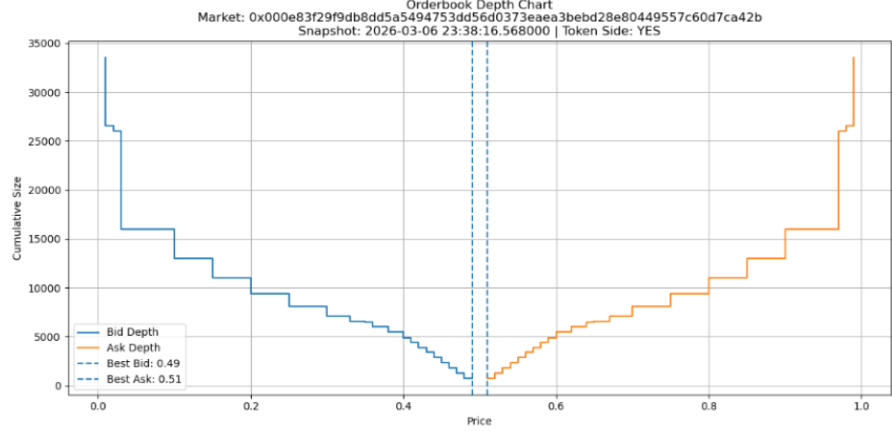

If we were to expand the graph above to show the depth chart **over time** to view how manipulators send ask level/ sell orders in bulk at different levels, the graph would look like this below:  
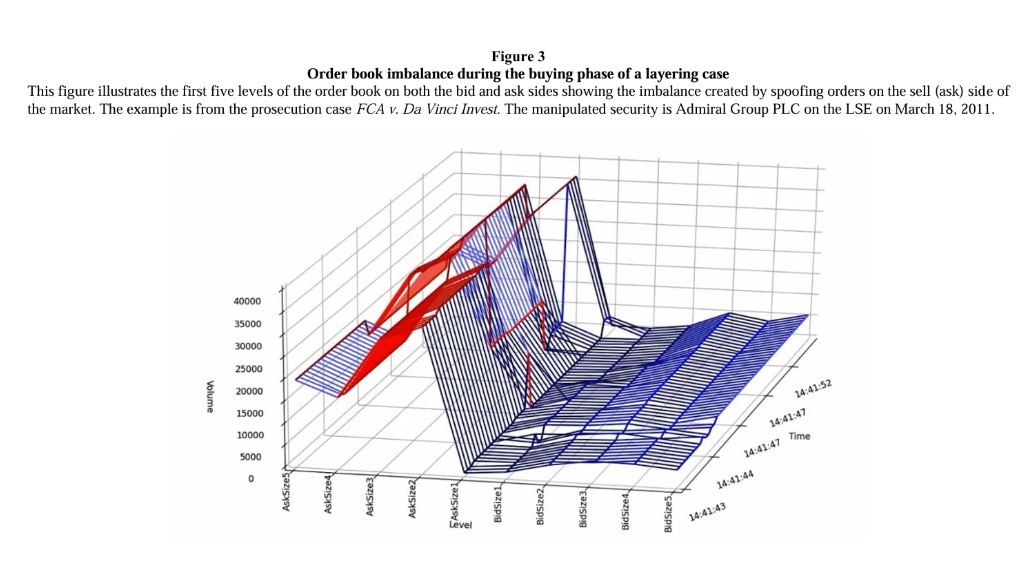  
The illustration shows how manipulators create bulk orders at different levels, in this case observe the giant triangles at different levels, to trick market participants of high market activity encouraging them lo lower their asking price/sell price in order to maintain execution priority (meaning first to trade/match with a bidder/buyer). Once the market has lowered its price, manipulators then BUY all the lowered price shares and then CANCEL their bulk orders.

The pattern is then repeated on the selling phase where the same tactic is used on the bidding side to again trick market participants to increase their bid price, manipulators then sell their shares at the increased price, and then CANCEL all their bulk orders.|

Following the detection logic from layering/spoofing literature, this section looks for:

1. Abnormally large order-book cancellations
2. High order-book update activity
3. Strong one-sided order-book imbalance
4. Cancellations shortly after liquidity additions
5. Activity across multiple price levels

We will then create a **score for Layering likelihood** by calculating the following:
| Metric | Description | Why it can indicate layering |
|---|---|---|
| `event_count` | Number of orderbook updates in a time window | Layering often involves rapid placement/cancellation bursts, which increases update frequency. |
| `activity_z` | How abnormal current event activity is vs recent baseline | High z-score means activity is unusually elevated relative to normal behavior for that market. |
| `added_size` | Liquidity added to the book | Layering starts with posting visible size to create a misleading impression of depth/pressure. |
| `cancelled_size` | Liquidity removed from the book | Spoof/layer orders are commonly pulled before execution, causing large removals. |
| `cancel_ratio` | Cancelled size divided by added + cancelled size | A high ratio suggests much of posted liquidity is quickly withdrawn rather than traded. |
| `affected_price_levels` | Number of price levels touched | Layering is typically distributed across multiple levels to make pressure look broad and credible. |
| `simple_layering_flag` | Threshold Rules combining high activity, high cancel ratio, cancellations, and multiple price levels | Flags windows where several layering-like signals appear together, reducing reliance on any single metric. |


Function Setup: Filtering Orderbook to only Important Markets by Liquidity and Volume

In [168]:
from pyspark.sql import functions as F
from pathlib import Path
import os
import glob


def load_and_filter_orderbook_by_market_quality(
    orderbook_path_or_dir,
    targets_path,
    max_files=1,
    orderbook_glob="orderbook_*.parquet",
    market_id_col_orderbook="market_id",
    market_id_col_targets="condition_id",
    volume_col="volume",
    liquidity_col="liquidity",
    p_low=95.0,
    p_high=99.9,
    filter_mode="volume",  # "volume", "liquidity", or "both"
    keep_cols=None,
    save_filtered=True,
    output_dir="/mnt/processed/private/msds2026/slt3a/Lab 1/data",
    output_prefix="filtered_orderbook_layering",
    save_mode="overwrite",
):
    """
    Loads one or more orderbook parquet files, filters to selected markets
    based on volume/liquidity percentile bounds from market_targets, and
    optionally saves the filtered result.

    Parameters
    ----------
    orderbook_path_or_dir : str
        Either:
        - a single parquet file path, e.g.
          /mnt/data/public/polymarket/orderbook/orderbook_2026-03-06.parquet
        - or a directory containing parquet files, e.g.
          /mnt/data/public/polymarket/orderbook

    max_files : int
        Number of orderbook parquet files to load. Start with 1 for testing.

    orderbook_glob : str
        Glob pattern used if orderbook_path_or_dir is a directory.

    filter_mode : str
        "volume", "liquidity", or "both".

    save_filtered : bool
        If True, saves filtered result to output_dir.

    Returns
    -------
    dict
        {
            "orderbook_df": raw loaded orderbook Spark DataFrame,
            "filtered_orderbook_df": filtered Spark DataFrame,
            "selected_markets_df": selected market metadata Spark DataFrame,
            "bounds": percentile bounds used,
            "input_paths": list of loaded parquet paths,
            "save_path": saved parquet path or None
        }
    """

    if filter_mode not in ["volume", "liquidity", "both"]:
        raise ValueError("filter_mode must be one of: 'volume', 'liquidity', 'both'")

    # ------------------------------------------------------------
    # 1. Resolve orderbook parquet paths
    # ------------------------------------------------------------
    if orderbook_path_or_dir.endswith(".parquet"):
        input_paths = [orderbook_path_or_dir]
    else:
        search_pattern = os.path.join(orderbook_path_or_dir, orderbook_glob)
        input_paths = sorted(glob.glob(search_pattern))

        if len(input_paths) == 0:
            raise FileNotFoundError(f"No parquet files found with pattern: {search_pattern}")

        input_paths = input_paths[:max_files]

    if max_files is not None:
        input_paths = input_paths[:max_files]

    print("Orderbook files selected:")
    for p in input_paths:
        print(" -", p)

    # ------------------------------------------------------------
    # 2. Build output filename using original parquet names
    # ------------------------------------------------------------
    base_names = [Path(p).stem for p in input_paths]

    if len(base_names) == 1:
        file_tag = base_names[0]
    else:
        file_tag = f"{base_names[0]}_to_{base_names[-1]}_{len(base_names)}files"

    save_path = os.path.join(
        output_dir,
        f"{output_prefix}_{file_tag}_{filter_mode}_p{p_low:g}_to_p{p_high:g}.parquet"
    )

    # ------------------------------------------------------------
    # 3. Load orderbook data
    # ------------------------------------------------------------
    orderbook_df = spark.read.parquet(*input_paths)

    if keep_cols is None:
        keep_cols = [
            "timestamp_received",
            market_id_col_orderbook,
            "best_bid",
            "best_ask",
            "change_price",
            "change_size",
            "change_side",
            "token_id",
            "spread",
            "mid_price",
        ]

    existing_keep_cols = [c for c in keep_cols if c in orderbook_df.columns]

    missing_cols = [c for c in keep_cols if c not in orderbook_df.columns]
    if missing_cols:
        print("Warning: these requested columns were not found and will be skipped:")
        print(missing_cols)

    # ------------------------------------------------------------
    # 4. Load market targets and calculate percentile bounds
    # ------------------------------------------------------------
    targets_df = spark.read.parquet(targets_path)

    targets_clean = (
        targets_df
        .withColumn("market_id_clean", F.col(market_id_col_targets).cast("string"))
        .withColumn("volume_clean", F.col(volume_col).cast("double"))
        .withColumn("liquidity_clean", F.col(liquidity_col).cast("double"))
    )

    bounds = {}

    if filter_mode in ["volume", "both"]:
        vol_bounds = (
            targets_clean
            .select(
                F.expr(f"percentile_approx(volume_clean, {p_low / 100})").alias("volume_min"),
                F.expr(f"percentile_approx(volume_clean, {p_high / 100})").alias("volume_max")
            )
            .collect()[0]
        )

        bounds["volume_min"] = vol_bounds["volume_min"]
        bounds["volume_max"] = vol_bounds["volume_max"]

    if filter_mode in ["liquidity", "both"]:
        liq_bounds = (
            targets_clean
            .select(
                F.expr(f"percentile_approx(liquidity_clean, {p_low / 100})").alias("liquidity_min"),
                F.expr(f"percentile_approx(liquidity_clean, {p_high / 100})").alias("liquidity_max")
            )
            .collect()[0]
        )

        bounds["liquidity_min"] = liq_bounds["liquidity_min"]
        bounds["liquidity_max"] = liq_bounds["liquidity_max"]

    # ------------------------------------------------------------
    # 5. Select markets based on volume/liquidity settings
    # ------------------------------------------------------------
    selected_markets_df = targets_clean

    if filter_mode in ["volume", "both"]:
        selected_markets_df = selected_markets_df.filter(
            F.col("volume_clean").between(
                F.lit(bounds["volume_min"]),
                F.lit(bounds["volume_max"])
            )
        )

    if filter_mode in ["liquidity", "both"]:
        selected_markets_df = selected_markets_df.filter(
            F.col("liquidity_clean").between(
                F.lit(bounds["liquidity_min"]),
                F.lit(bounds["liquidity_max"])
            )
        )

    selected_markets_df = (
        selected_markets_df
        .select(
            F.col("market_id_clean").alias("market_id"),
            F.col("volume_clean").alias("volume"),
            F.col("liquidity_clean").alias("liquidity")
        )
        .distinct()
    )

    selected_market_count = selected_markets_df.count()

    print(f"Filter mode: {filter_mode}")
    print("Bounds:", bounds)
    print(f"Selected markets: {selected_market_count:,}")

    # ------------------------------------------------------------
    # 6. Filter orderbook before expensive layering calculations
    # ------------------------------------------------------------
    filtered_orderbook_df = (
        orderbook_df
        .select(*existing_keep_cols)
        .withColumn("market_id", F.col(market_id_col_orderbook).cast("string"))
        .join(
            selected_markets_df.select("market_id"),
            on="market_id",
            how="inner"
        )
        .filter(F.col("change_side").isin("BUY", "SELL"))
        .filter(F.col("change_size").isNotNull())
        .filter(F.col("change_price").isNotNull())
    )

    # ------------------------------------------------------------
    # 7. Save filtered result
    # ------------------------------------------------------------
    if save_filtered:
        print("Saving filtered orderbook to:")
        print(save_path)

        (
            filtered_orderbook_df
            .write
            .mode(save_mode)
            .parquet(save_path)
        )

        print("Saved.")

    return {
        "orderbook_df": orderbook_df,
        "filtered_orderbook_df": filtered_orderbook_df,
        "selected_markets_df": selected_markets_df,
        "bounds": bounds,
        "input_paths": input_paths,
        "save_path": save_path if save_filtered else None,
    }

In [ ]:
import os
from glob import glob

orderbook_dir = "/mnt/data/public/polymarket/orderbook"
targets_path = "/mnt/data/public/polymarket/labels/market_targets.parquet"

all_orderbook_files = sorted(glob(os.path.join(orderbook_dir, "orderbook_*.parquet")))
print(f"Found {len(all_orderbook_files)} files")

all_results = []

for i, ob_path in enumerate(all_orderbook_files, 1):
    print(f"\n[{i}/{len(all_orderbook_files)}] Processing: {os.path.basename(ob_path)}")
    
    result = load_and_filter_orderbook_by_market_quality(
        orderbook_path_or_dir=ob_path,
        targets_path=targets_path,
        max_files=1,          # keep 1 since we're already looping file-by-file
        filter_mode="both",
        p_low=95.0,
        p_high=99.9,
        save_filtered=True,
    )
    
    all_results.append({
        "input_file": ob_path,
        "save_path": result.get("save_path")
    })

print("\nDone.")
print("Example saved path:", all_results[0]["save_path"] if all_results else None)


Layering Function Calculation Run

In [170]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import os


def detect_layering_from_saved_orderbook(
    saved_orderbook_path,
    time_window="1 minute",
    baseline_windows=60,
    activity_z_threshold=2.0,
    cancel_ratio_threshold=0.7,
    min_affected_price_levels=3,
    market_col="market_id",
    time_col="timestamp_received",
    price_col="change_price",
    size_col="change_size",
    side_col="change_side",
    token_col="token_id",
    save_results=True,
    output_dir="/mnt/processed/private/msds2026/slt3a/Lab 1/data",
    output_prefix="layering_detection",
    save_mode="overwrite",
):
    """
    Detects possible layering activity from a saved filtered orderbook parquet.

    This is a low-cost first-pass detector using:
    1. unusually high order-book event frequency
    2. high cancellation intensity
    3. activity across multiple price levels

    It is not proof of manipulation. It identifies candidate markets/windows
    for deeper inspection.

    Returns
    -------
    dict
        {
            "orderbook_df": loaded saved orderbook Spark DataFrame,
            "window_scores": per-market-window layering scores,
            "market_summary": market-level layering summary,
            "saved_window_scores_path": path or None,
            "saved_market_summary_path": path or None
        }
    """

    # ------------------------------------------------------------
    # 1. Load saved filtered orderbook
    # ------------------------------------------------------------
    print("Loading saved filtered orderbook from:")
    print(saved_orderbook_path)

    orderbook_df = spark.read.parquet(saved_orderbook_path)

    print("Loaded saved orderbook.")
    print("Columns:", orderbook_df.columns)

    # ------------------------------------------------------------
    # 2. Clean / normalize columns
    # ------------------------------------------------------------
    ob_clean = (
        orderbook_df
        .withColumn("event_time", F.to_timestamp((F.col(time_col) / 1000).cast("double")))
        .withColumn("market_id_clean", F.col(market_col).cast("string"))
        .withColumn("token_id_clean", F.col(token_col).cast("string"))
        .withColumn("side_clean", F.upper(F.col(side_col)))
        .withColumn("price_clean", F.col(price_col).cast("double"))
        .withColumn("size_clean", F.col(size_col).cast("double"))
        .filter(F.col("event_time").isNotNull())
        .filter(F.col("market_id_clean").isNotNull())
        .filter(F.col("token_id_clean").isNotNull())
        .filter(F.col("side_clean").isin("BUY", "SELL"))
        .filter(F.col("price_clean").isNotNull())
        .filter(F.col("size_clean").isNotNull())
    )

    # ------------------------------------------------------------
    # 3. Compute size deltas at each market/token/side/price level
    # ------------------------------------------------------------
    level_window = (
        Window
        .partitionBy(
            "market_id_clean",
            "token_id_clean",
            "side_clean",
            "price_clean"
        )
        .orderBy("event_time")
    )

    ob_deltas = (
        ob_clean
        .withColumn("prev_size", F.lag("size_clean").over(level_window))
        .withColumn(
            "delta_size",
            F.when(F.col("prev_size").isNull(), F.lit(0.0))
             .otherwise(F.col("size_clean") - F.col("prev_size"))
        )
        .withColumn(
            "added_size",
            F.when(F.col("delta_size") > 0, F.col("delta_size"))
             .otherwise(F.lit(0.0))
        )
        .withColumn(
            "cancelled_size",
            F.when(F.col("delta_size") < 0, -F.col("delta_size"))
             .otherwise(F.lit(0.0))
        )
    )

    # ------------------------------------------------------------
    # 4. Aggregate cheap layering features by market/time window
    # ------------------------------------------------------------
    layer_base = (
        ob_deltas
        .groupBy(
            "market_id_clean",
            F.window("event_time", time_window).alias("time_window")
        )
        .agg(
            F.count("*").alias("event_count"),
            F.sum("added_size").alias("added_size"),
            F.sum("cancelled_size").alias("cancelled_size"),
            F.countDistinct("price_clean").alias("affected_price_levels")
        )
        .select(
            F.col("market_id_clean").alias("market_id"),
            F.col("time_window.start").alias("window_start"),
            F.col("time_window.end").alias("window_end"),
            "event_count",
            "added_size",
            "cancelled_size",
            "affected_price_levels"
        )
        .withColumn(
            "cancel_ratio",
            F.col("cancelled_size") /
            (F.col("added_size") + F.col("cancelled_size") + F.lit(1e-9))
        )
    )

    # ------------------------------------------------------------
    # 5. Rolling event-frequency z-score
    # ------------------------------------------------------------
    baseline_window = (
        Window
        .partitionBy("market_id")
        .orderBy("window_start")
        .rowsBetween(-baseline_windows, -1)
    )

    window_scores = (
        layer_base
        .withColumn("event_count_mean", F.avg("event_count").over(baseline_window))
        .withColumn("event_count_std", F.stddev("event_count").over(baseline_window))
        .withColumn(
            "activity_z",
            F.when(
                F.col("event_count_std") > 0,
                (F.col("event_count") - F.col("event_count_mean")) /
                F.col("event_count_std")
            ).otherwise(F.lit(0.0))
        )
        .withColumn(
            "simple_layering_flag",
            (
                (F.col("activity_z") >= F.lit(activity_z_threshold)) &
                (F.col("cancel_ratio") >= F.lit(cancel_ratio_threshold)) &
                (F.col("cancelled_size") > 0) &
                (F.col("affected_price_levels") >= F.lit(min_affected_price_levels))
            )
        )
    )

    # ------------------------------------------------------------
    # 6. Market-level summary
    # ------------------------------------------------------------
    market_summary = (
        window_scores
        .groupBy("market_id")
        .agg(
            F.count("*").alias("num_windows"),
            F.sum(F.col("simple_layering_flag").cast("int")).alias("flagged_windows"),
            F.avg("event_count").alias("avg_event_count"),
            F.max("event_count").alias("max_event_count"),
            F.avg("activity_z").alias("avg_activity_z"),
            F.max("activity_z").alias("max_activity_z"),
            F.avg("cancel_ratio").alias("avg_cancel_ratio"),
            F.max("cancel_ratio").alias("max_cancel_ratio"),
            F.sum("cancelled_size").alias("total_cancelled_size"),
            F.sum("added_size").alias("total_added_size"),
            F.avg("affected_price_levels").alias("avg_affected_price_levels"),
            F.max("affected_price_levels").alias("max_affected_price_levels")
        )
        .withColumn(
            "flagged_window_rate",
            F.col("flagged_windows") / F.col("num_windows")
        )
        .orderBy(
            F.desc("flagged_windows"),
            F.desc("flagged_window_rate"),
            F.desc("max_activity_z")
        )
    )

    # ------------------------------------------------------------
    # 7. Save results
    # ------------------------------------------------------------
    saved_window_scores_path = None
    saved_market_summary_path = None

    if save_results:
        input_name = os.path.basename(saved_orderbook_path.rstrip("/"))
        if input_name.endswith(".parquet"):
            input_name = input_name.replace(".parquet", "")

        saved_window_scores_path = os.path.join(
            output_dir,
            f"{output_prefix}_window_scores_{input_name}.parquet"
        )

        saved_market_summary_path = os.path.join(
            output_dir,
            f"{output_prefix}_market_summary_{input_name}.parquet"
        )

        print("Saving window scores to:")
        print(saved_window_scores_path)

        (
            window_scores
            .write
            .mode(save_mode)
            .parquet(saved_window_scores_path)
        )

        print("Saving market summary to:")
        print(saved_market_summary_path)

        (
            market_summary
            .write
            .mode(save_mode)
            .parquet(saved_market_summary_path)
        )

        print("Saved layering detection results.")

    return {
        "orderbook_df": orderbook_df,
        "window_scores": window_scores,
        "market_summary": market_summary,
        "saved_window_scores_path": saved_window_scores_path,
        "saved_market_summary_path": saved_market_summary_path,
    }

Layering Calculation Function Run

In [ ]:
import os
import glob

# 1) folder where filtered parquet files were saved
filtered_dir = "/mnt/processed/private/msds2026/slt3a/Lab 1/data"
pattern = os.path.join(filtered_dir, "filtered_orderbook_layering*.parquet")
all_filtered_files = sorted(glob.glob(pattern))

print(f"Found {len(all_filtered_files)} filtered parquet files")

all_layering_results = []

for i, saved_orderbook_path in enumerate(all_filtered_files, 1):
    print(f"\n[{i}/{len(all_filtered_files)}] Layering on: {os.path.basename(saved_orderbook_path)}")

    res = detect_layering_from_saved_orderbook(
        saved_orderbook_path=saved_orderbook_path,
        time_window="1 hour",
        baseline_windows=60,
        activity_z_threshold=2.0,
        cancel_ratio_threshold=0.7,
        min_affected_price_levels=3,
        save_results=True
    )

    all_layering_results.append({
        "input_path": saved_orderbook_path,
        "window_scores_path": res["saved_window_scores_path"],
        "market_summary_path": res["saved_market_summary_path"]
    })

print("\nDone.")
print("Example output:", all_layering_results[0] if all_layering_results else None)


Combining All Daily Analyzed Results into One 

In [ ]:
import os
import glob
from pyspark.sql import functions as F

# 1) Load all per-file market summaries
base_dir = "/mnt/processed/private/msds2026/slt3a/Lab 1/data"
summary_pattern = os.path.join(base_dir, "layering_detection_market_summary_*.parquet")
summary_files = sorted(glob.glob(summary_pattern))

print(f"Found {len(summary_files)} market-summary parquet files")
if not summary_files:
    raise ValueError("No market summary files found.")

all_summary_df = spark.read.parquet(*summary_files)

# 2) Combine per market across all files
combined_market_ranking = (
    all_summary_df
    .groupBy("market_id")
    .agg(
        F.sum("num_windows").alias("num_windows_total"),
        F.sum("flagged_windows").alias("flagged_windows_total"),
        F.max("max_activity_z").alias("max_activity_z_global"),
        F.max("max_cancel_ratio").alias("max_cancel_ratio_global"),
        F.sum("total_cancelled_size").alias("total_cancelled_size_global"),
        F.sum("total_added_size").alias("total_added_size_global"),

        # weighted averages by window count
        (F.sum(F.col("avg_event_count") * F.col("num_windows")) / F.sum("num_windows")).alias("avg_event_count_weighted"),
        (F.sum(F.col("avg_activity_z") * F.col("num_windows")) / F.sum("num_windows")).alias("avg_activity_z_weighted"),
        (F.sum(F.col("avg_cancel_ratio") * F.col("num_windows")) / F.sum("num_windows")).alias("avg_cancel_ratio_weighted"),
        (F.sum(F.col("avg_affected_price_levels") * F.col("num_windows")) / F.sum("num_windows")).alias("avg_affected_price_levels_weighted"),
    )
    .withColumn(
        "flagged_window_rate_global",
        F.col("flagged_windows_total") / (F.col("num_windows_total") + F.lit(1e-9))
    )
    .withColumn(
        "layering_likelihood_score",
        100 * (
            0.55 * F.col("flagged_window_rate_global") +
            0.30 * F.least(F.col("avg_activity_z_weighted") / F.lit(5.0), F.lit(1.0)) +
            0.15 * F.least(F.col("avg_cancel_ratio_weighted"), F.lit(1.0))
        )
    )
    .orderBy(
        F.desc("layering_likelihood_score"),
        F.desc("flagged_windows_total"),
        F.desc("max_activity_z_global")
    )
)

# 3) Save combined ranking
combined_out_path = os.path.join(base_dir, "layering_detection_market_summary_combined_ranked.parquet")
combined_market_ranking.write.mode("overwrite").parquet(combined_out_path)

print("Saved combined ranking to:", combined_out_path)

# 4) Show top markets
display(combined_market_ranking.limit(30))


Viewing Combined Daily Results Table and Adding the Required Labels and Market Questions

In [174]:
# View top rows as a table first
combined_out_path = "/mnt/processed/private/msds2026/slt3a/Lab 1/data/layering_detection_market_summary_combined_ranked.parquet"

ranked_df = spark.read.parquet(combined_out_path)
top_table = (
    ranked_df
    .orderBy(F.desc("layering_likelihood_score"))
    .limit(30)
    .toPandas()
)
display(top_table.head(10))

from pyspark.sql import functions as F

# Paths
ranked_path = "/mnt/processed/private/msds2026/slt3a/Lab 1/data/layering_detection_market_summary_combined_ranked.parquet"
classified_path = "slt3a/Lab 1/data/market_targets_classified_all.parquet"

# Load
ranked_df = spark.read.parquet(ranked_path)
classified_df = spark.read.parquet(classified_path)

# Keep market text + top1_label
meta_df = (
    classified_df
    .select(
        F.col("condition_id").cast("string").alias("market_id"),
        F.col("question"),
        F.col("top1_label")
    )
    .dropDuplicates(["market_id"])
)

# Join
combined_enriched_df = (
    ranked_df
    .withColumn("market_id", F.col("market_id").cast("string"))
    .join(meta_df, on="market_id", how="left")
    .orderBy(F.desc("layering_likelihood_score"))
)

print("Top Markets Ranked by Layering Likelihood Score")
# View
display(
    combined_enriched_df.select(
        "market_id",
        "question",
        "top1_label",
        "layering_likelihood_score",
        "flagged_windows_total",
        "num_windows_total",
        "flagged_window_rate_global",
        "avg_activity_z_weighted",
        "avg_cancel_ratio_weighted",
    )
    .dropna(subset=["question", "top1_label"])  # drop rows with missing question/label
    # .limit(50)
    .toPandas()
)

# Save
enriched_out = "/mnt/processed/private/msds2026/slt3a/Lab 1/data/layering_detection_market_summary_combined_ranked_with_labels.parquet"
combined_enriched_df.write.mode("overwrite").parquet(enriched_out)
print("Saved:", enriched_out)


,market_id,num_windows_total,flagged_windows_total,max_activity_z_global,max_cancel_ratio_global,total_cancelled_size_global,total_added_size_global,avg_event_count_weighted,avg_activity_z_weighted,avg_cancel_ratio_weighted,avg_affected_price_levels_weighted,flagged_window_rate_global,layering_likelihood_score
0,0x896c5c288315ff3ecd98516ddc8848868c03040ac911...,24,1,174.251314,0.900781,5.440247e+05,2.933576e+05,1037.791667,7.714604,0.660906,180.041667,0.041667,42.205257
1,0x82e61515e1c0b5ac3a2d99ad187815f400b03dc4ddb7...,13,1,121.680980,1.000000,1.081748e+05,9.566700e+04,211.615385,11.013604,0.526613,13.307692,0.076923,42.129960
2,0xecdf42488da999b04ab160c1ad7997249d4ef0facb28...,17,1,160.095429,0.979901,8.616663e+05,8.576409e+05,457.294118,10.170452,0.556872,13.647059,0.058824,41.588374
3,0x81666ac08b14252b7f258434c1d051eeee037f77385b...,24,1,213.647263,0.766479,6.200358e+05,5.304854e+05,264.083333,9.163148,0.543057,65.000000,0.041667,40.437527
4,0xa31552e6636ba966681f1e2af0351b288c157e5f5748...,24,1,123.529885,0.915896,3.741795e+05,2.542621e+05,177.291667,5.484885,0.538217,58.458333,0.041667,40.364919
5,0x8bf6339043795509309d23e44a38b070347198b52722...,18,1,81.119604,1.000000,1.474103e+07,1.505013e+07,6843.000000,7.348268,0.461976,36.166667,0.055556,39.985193
6,0x180cad29950aab8a08730c47e904416559aad814321d...,24,1,178.898016,0.880883,4.878043e+05,4.575907e+05,233.208333,7.462869,0.508020,30.416667,0.041667,39.911966
7,0x7b778a4ed998b1b35d329d2b0f79ce2ab7b9273a95e5...,32,1,192.259036,1.000000,2.809167e+07,2.838941e+07,3444.718750,7.388730,0.427955,23.468750,0.031250,38.138076
8,0xbd0f93cf9dd1dac4c2b7125bb13bb8d2f492a260f484...,11,0,80.793458,1.000000,1.544456e+04,1.800673e+04,61.636364,7.456827,0.537557,2.090909,0.000000,38.063360
9,0x596b82d8371efcfcc2fd5312d5dde04f5e9aa1f0c61f...,552,0,1523.815113,0.967440,2.790793e+07,3.590357e+07,535.356884,8.439358,0.534817,75.389493,0.000000,38.022251


Top Markets Ranked by Layering Likelihood Score


,market_id,question,top1_label,layering_likelihood_score,flagged_windows_total,num_windows_total,flagged_window_rate_global,avg_activity_z_weighted,avg_cancel_ratio_weighted
0,0x82e61515e1c0b5ac3a2d99ad187815f400b03dc4ddb7...,Spread: Houston Astros (-1.5),sports,42.129960,1,13,0.076923,11.013604,0.526613
1,0x8bf6339043795509309d23e44a38b070347198b52722...,Counter-Strike: DashSkins vs UNO MILLE (BO3) -...,entertainment,39.985193,1,18,0.055556,7.348268,0.461976
2,0x7b778a4ed998b1b35d329d2b0f79ce2ab7b9273a95e5...,Bitcoin Up or Down on March 27?,crypto,38.138076,1,32,0.031250,7.388730,0.427955
3,0xbd0f93cf9dd1dac4c2b7125bb13bb8d2f492a260f484...,NRFI: Boston Red Sox vs. Cincinnati Reds,sports,38.063360,0,11,0.000000,7.456827,0.537557
4,0x87cfa4eeb148ea2b725e696c6daaa570f8fd89bd7433...,Will Wei Yi win the 2026 FIDE Candidates Tourn...,others,37.969556,0,7,0.000000,5.589391,0.531304
...,...,...,...,...,...,...,...,...,...
2628,0x2ad5330f5bde27e76518b117ea75dfe39dd4c680e947...,Over $14M committed to the P2P Protocol public...,finance,-5.019940,0,4,0.000000,-0.883883,0.018891
2629,0x8155c0f479abe32b2f9c731377f5ae83a85190f0adab...,Over $16M committed to the P2P Protocol public...,finance,-5.303301,0,4,0.000000,-0.883883,0.000000
2630,0x8f0de3bde52136e0cbaa9ad698a95861539d0ba66d16...,Will Russia enter Sloviansk by June 30?,world events,-8.081248,1,552,0.001812,-2.603854,0.496149
2631,0xd46d9032162c7d8db1b397ef40a3a64e23306455a335...,"Will the price of Bitcoin be between $72,000 a...",crypto,-11.907824,0,57,0.000000,-3.246179,0.504617


Saved: /mnt/processed/private/msds2026/slt3a/Lab 1/data/layering_detection_market_summary_combined_ranked_with_labels.parquet


**Observation**  
Here weve ranked all the markets for Layering and categorized them with their appropriate question labels from the transformer. Now we see variety of markets that have a high likelihood for layering manipulation. 

### Market Category Analysis

In [218]:
import plotly.express as px

box_pdf = (
    combined_enriched_df
    .select("top1_label", "layering_likelihood_score")
    .dropna(subset=["top1_label", "layering_likelihood_score"])
    .toPandas()
)

# --- Outlier threshold (global IQR rule) ---
q1 = box_pdf["layering_likelihood_score"].quantile(0.1)
q3 = box_pdf["layering_likelihood_score"].quantile(0.90)
iqr = q3 - q1

k = 1.5  # increase to 2.0 or 3.0 for less aggressive filtering
lower = q1 - k * iqr
upper = q3 + k * iqr

box_pdf_filtered = box_pdf[
    box_pdf["layering_likelihood_score"].between(lower, upper)
].copy()

print(f"Kept {len(box_pdf_filtered):,} / {len(box_pdf):,} rows")
print(f"Thresholds: lower={lower:.4f}, upper={upper:.4f}")

fig = px.box(
    box_pdf_filtered,
    x="top1_label",
    y="layering_likelihood_score",
    points="outliers",
    title=f"Distribution of Layering Likelihood Score by top1_label (IQR filtered, k={k})"
)

fig.update_layout(
    xaxis_title="top1_label",
    yaxis_title="Layering Likelihood Score",
    xaxis_tickangle=-35,
    height=650,
    width=1200
)

fig.show()


Kept 2,558 / 2,633 rows
Thresholds: lower=-0.7794, upper=22.5717


**Observation**  
Here we see a slightly different behavior. Unlike pump and dump, layering is a more calculated strategy relying on quicker price movements and market reaction inoder to manipulate the public. Interestingly we see Crypto to have the highest likelihood for layering which is often dominated with faster paced transactions, big news hypes, and heavily controlled with algorithmic trading. It is the perfect enivronment to deploy and even simulate large amounts of different strategies increasing the probability of manipulative strategies like layering to be involved as well.

 We also see a high likelihood of layering in culture categories which often involves entertainment related markets as we ll such as Will "I Just Might - Bruno Mars" be the Billboard #1 song for the week of April 4?, Will Paramount close Warner Bros acquisition?, or Taylor Swift pregnant before marriage?. This can also explain how its about the same average score with entertainment markets. Surprisingly politics and world events have low layering likelihoods which are often stereotypically believed to have high insider information activity. This can be true in a sense where layering is not effective if insider information favors pump and dump strategy. 

# Conclusion and Summary

## Limitations

1. **No fraud labels.** The dataset does not provide confirmed fraud/manipulation labels, so the notebook uses rule-based anomaly scoring rather than supervised fraud classification.
2. **No proof of intent.** The score identifies abnormal behavior, not trader intent or legal manipulation.
3. **Partial metadata coverage.** Only orderbook markets that successfully join to the labels table are used for interpretable market-level reporting.
4. **Resource-constrained MVP.** The notebook includes safe-mode processing and checkpointing to handle local Spark limitations. In larger Spark infrastructure, the same logic can be scaled to more markets and more orderbook days.
5. **Keyword-based categories.** Topic categories are created from market question text using rules because the original category field is mostly blank.
6. **Limited orderbook depth.** The MVP uses available top-level orderbook fields and change events. Full spoofing/layering detection would require deeper book-level data and order-cancellation behavior.
7. **Heuristic weights.** The Buyer Risk Score weights are explainable design choices for the MVP. They should be calibrated with expert review, labeled events, or historical backtesting in future versions.

## Future Improvements

1. Process multiple days of orderbook data.
2. Add unsupervised machine learning such as clustering or Isolation Forest after the rule-based MVP is stable.
3. Replace keyword topic rules with a stronger NLP classifier.
4. Validate high-risk windows against external news or major event timestamps.
5. Add full orderbook depth features if available.
6. Calibrate score weights using expert review or known abnormal market examples.
7. Build a simple dashboard for buyer-facing review.

## Sources and Method Support

The scoring logic is an original, explainable MVP design. The sources below support the broader methodological basis: anomaly detection, financial fraud/risk screening, transaction-pattern analysis, explainability, and AI use in finance.

1. Deepak. (2025). *AI in Finance: Fraud Detection, Algorithmic Trading, and Risk Assessment*. International Journal of Applied and Behavioural Sciences, 02(02), 37–48. DOI: https://doi.org/10.70388/ijabs250135.
2. Bolton, R. J., & Hand, D. J. (2002). Statistical fraud detection: A review. *Statistical Science*, 17(3), 235–255. https://doi.org/10.1214/ss/1042727940
3. Ngai, E. W. T., Hu, Y., Wong, Y. H., Chen, Y., & Sun, X. (2011). The application of data mining techniques in financial fraud detection: A classification framework and an academic review of literature. *Decision Support Systems*, 50(3), 559–569. https://doi.org/10.1016/j.dss.2010.08.006
4. West, J., & Bhattacharya, M. (2016). Intelligent financial fraud detection: A comprehensive review. *Computers & Security*, 57, 47–66. https://doi.org/10.1016/j.cose.2015.09.005
5. Jain, V., Kumar, R., & Sharma, D. (2022). Financial fraud detection using ensemble learning. *Expert Systems with Applications*, 193, Article 116421. https://doi.org/10.1016/j.eswa.2021.116421
6. Bhatia, M., & Kumar, A. (2020). Artificial intelligence in compliance and risk management in the financial sector. *Journal of Financial Regulation and Compliance*, 28(3), 313–328. https://doi.org/10.1108/JFRC-12-2019-0154
7. Treleaven, P., Galas, M., & Lalchand, V. (2013). Algorithmic trading and machine learning. *The Computer Journal*, 56(5), 491–510. https://doi.org/10.1093/comjnl/bxt067
8. Goodell, J. W., Huynh, T. L. D., & Vo, X. V. (2021). Risks and returns of cryptocurrency: Evidence from a new dataset. *Journal of Risk and Financial Management*, 14(6), 252. https://doi.org/10.3390/jrfm14060252